In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from scipy.stats import skew 
from scipy.stats import kurtosis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib.ticker import MultipleLocator
from sklearn.preprocessing import PowerTransformer
from matplotlib.ticker import FuncFormatter


In [2]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'
#fpath = 'C:\\Users\\gianl\\Desktop\\Actigraphy Sara'

In [3]:
df = pd.read_excel(fpath + '\\8.0_database_variables.xlsx', sheet_name = 'clean')

In [4]:
# Rename columns
df = df.rename(columns={'location(ita=0,uk=1)': 'location', 'week(1=free days)': 'weekday_type'})

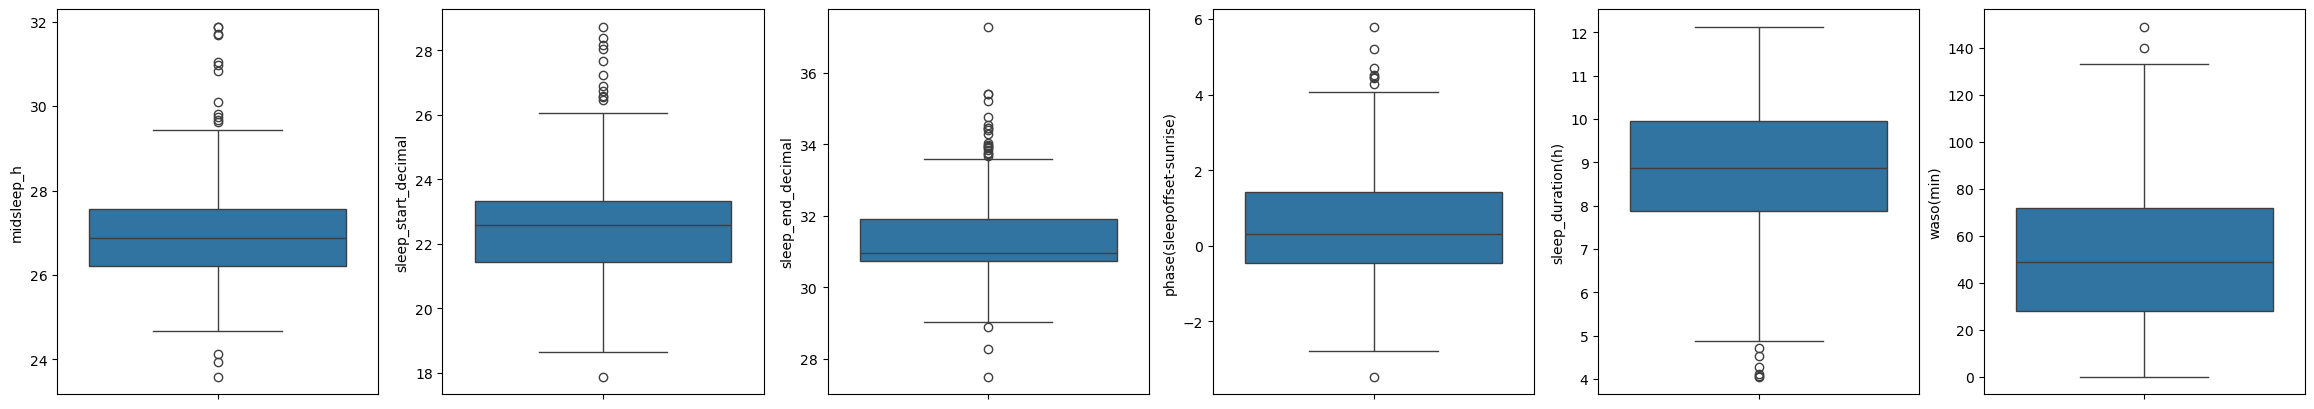

In [5]:
# box plot to verify the outliers
fig, ax = plt.subplots(1, 6, figsize=(29, 5))
sns.boxplot(data=df['midsleep_h'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)'], ax=ax[4])
sns.boxplot(data=df['waso(min)'], ax=ax[5])

plt.show()

In [6]:
# remove outliers
# criteria: zscore of 3 means that the data point is 3 standard deviations away from the mean
df = df[(np.abs(stats.zscore(df['midsleep_h'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_duration(h)'])) < 3)]

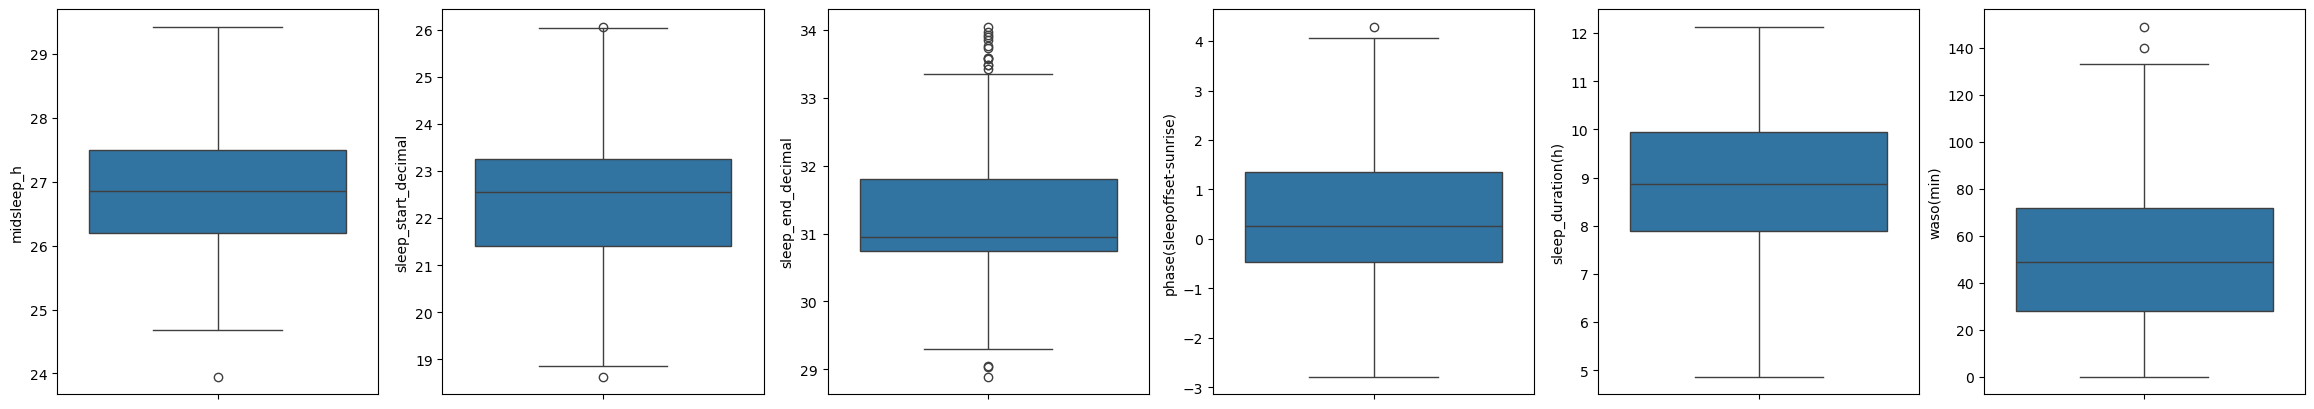

In [7]:
# box plot to verify the outliers
fig, ax = plt.subplots(1, 6, figsize=(29, 5))
sns.boxplot(data=df['midsleep_h'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)'], ax=ax[4])
sns.boxplot(data=df['waso(min)'], ax=ax[5])

plt.show()

In [8]:
# define the start date
start_date = pd.to_datetime('2022-02-01')

In [9]:
# function to count the week of the year from the start date 2022-02-01
def calculate_week_of_year(start_datetime): return (start_datetime - start_date).days // 7 + 5

# apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [10]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [11]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [12]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)'] = df['sleep_duration(h)'].astype(float)
df['sleep_duration_work_days'] = df['sleep_duration(h)'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days'] = df['sleep_duration(h)'] * (df['weekday_type'] == 'free days')

In [13]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [14]:
# create a new df for weekly jetlag analysis
data_jetlag = df 

In [15]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag = data_jetlag.groupby(['location', 'week_of_year', 'weekday_type'])['midsleep_h'].mean().unstack()

In [16]:
# calculate the jet lag 
weekly_means_jetlag['jet lag'] = weekly_means_jetlag['free days'] - weekly_means_jetlag['work days']

In [17]:
# add a column with the location to the weekly_means_jetlag_UTC
weekly_means_jetlag['location'] = weekly_means_jetlag.index.get_level_values(0)

In [18]:
# rename columns
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})
df = df.rename(columns={'waso(min)': 'waso'})
df = df.rename(columns={'DST(0=ST)': 'DST_1'})

In [19]:
# dictionary with the season dates
seasons = {'Winter': [(12, 21), (3, 20)], 'Spring': [(3, 21), (6, 20)], 'Summer': [(6, 21), (9, 22)], 'Autumn': [(9, 23), (12, 20)]}

df['date'] = pd.to_datetime(df['date'])

In [20]:
# Function to get the season from the date
def get_season(date):
    month, day = date.month, date.day
    for season, ((start_month, start_day), (end_month, end_day)) in seasons.items():
        if (month == start_month and day >= start_day) or (month == end_month and day <= end_day):
            return season
        elif start_month < month < end_month:
            return season
    return 'Winter'  # for dates before 21st December and after 20th December

In [21]:
# Applying the function to create a season column
df_workdays.loc[:, 'season'] = df_workdays['date'].apply(get_season)
df_freedays.loc[:, 'season'] = df_freedays['date'].apply(get_season)
df.loc[:, 'season'] = df['date'].apply(get_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_15384\2634099026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[:, 'season'] = df_workdays['date'].apply(get_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_15384\2634099026.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[:, 'season'] = df_freedays['date'].apply(get_season)


In [22]:
# new variable 'photoperiod' based on the location
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])

In [23]:
# add a column with the photoperiod for the UK and ITA
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] 
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_15384\1608732957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']


In [24]:
# add the photoperiod column to the df_freedays
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_15384\2381324628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [25]:
# descpriptive statistics
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [26]:
# add the index as a column
all_descriptive['variable'] = all_descriptive.index 

In [27]:
#reset the index
all_descriptive = all_descriptive.reset_index(drop=True)

In [28]:
all_descriptive.to_excel(fpath + '\\all_descriptive.xlsx')

In [170]:
#descriptive for workdays and freedays
workdays_descriptive = df_workdays.describe()
workdays_descriptive = workdays_descriptive.transpose()

# add the index as a column
workdays_descriptive['variable'] = workdays_descriptive.index

#reset the index
workdays_descriptive = workdays_descriptive.reset_index(drop=True)

In [171]:
# save the descriptive statistics for freedays
freedays_descriptive = df_freedays.describe()
freedays_descriptive = freedays_descriptive.transpose()

# add the index as a column
freedays_descriptive['variable'] = freedays_descriptive.index

#reset the index
freedays_descriptive = freedays_descriptive.reset_index(drop=True)

In [29]:
# descpriptive statistics for ITA
descriptive_ita = df[df['location'] == 'ITA'].describe()
descriptive_ita = descriptive_ita.transpose()

In [30]:
descriptive_ita.to_excel(fpath + '\\descriptive_ita.xlsx')

In [31]:
# descpriptive statistics for UK
descriptive_uk = df[df['location'] == 'UK'].describe()
descriptive_uk = descriptive_uk.transpose()

In [32]:
descriptive_uk.to_excel(fpath + '\\descriptive_uk.xlsx')

In [33]:
# % of time spent in each location
count_location = df['location'].value_counts(normalize=True) * 100

In [34]:
count_location

location
ITA    58.211382
UK     41.788618
Name: proportion, dtype: float64

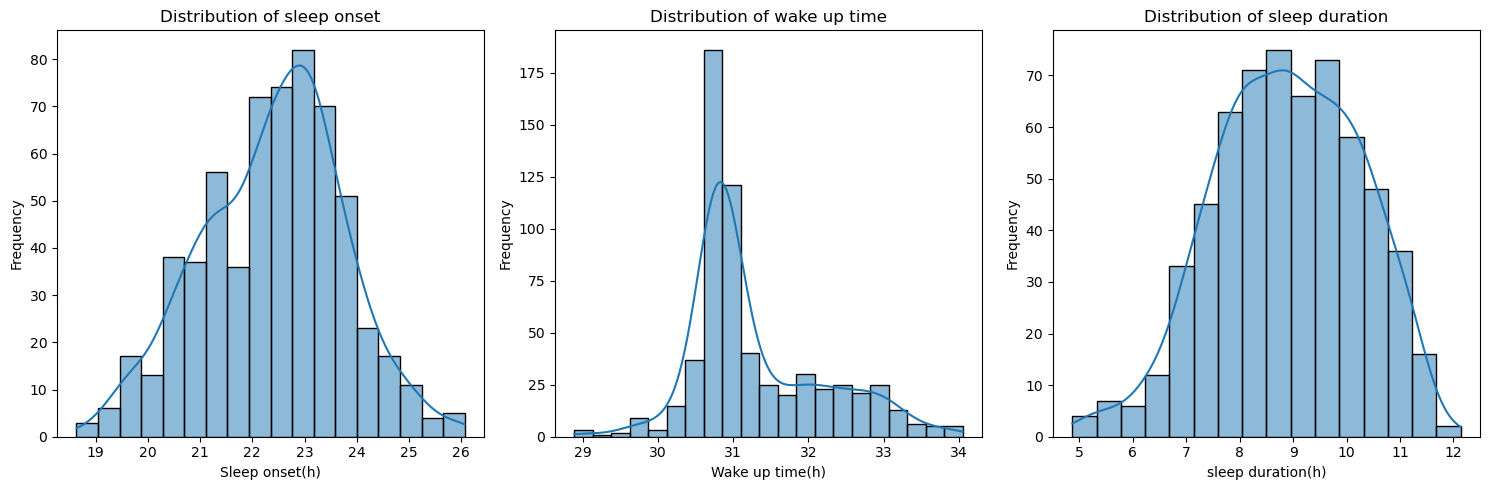

In [35]:
# distribution of the midpoint, sleep onset, sleep offset, and sleep duration
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal'].dropna(), kde=True)
plt.title("Distribution of wake up time")
plt.xlabel("Wake up time(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

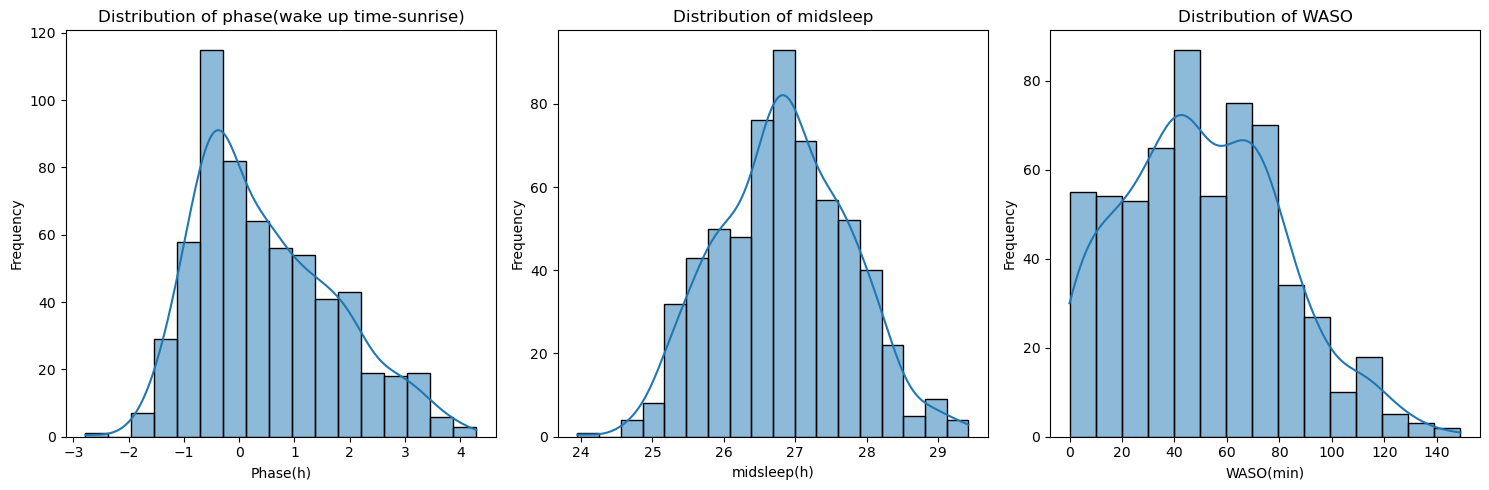

In [36]:
# distribution of phase and midpoint of sleep
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(wake up time-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='midsleep_h', kde=True)
plt.title("Distribution of midsleep")
plt.xlabel("midsleep(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='waso', kde=True)
plt.title("Distribution of WASO")
plt.xlabel("WASO(min)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

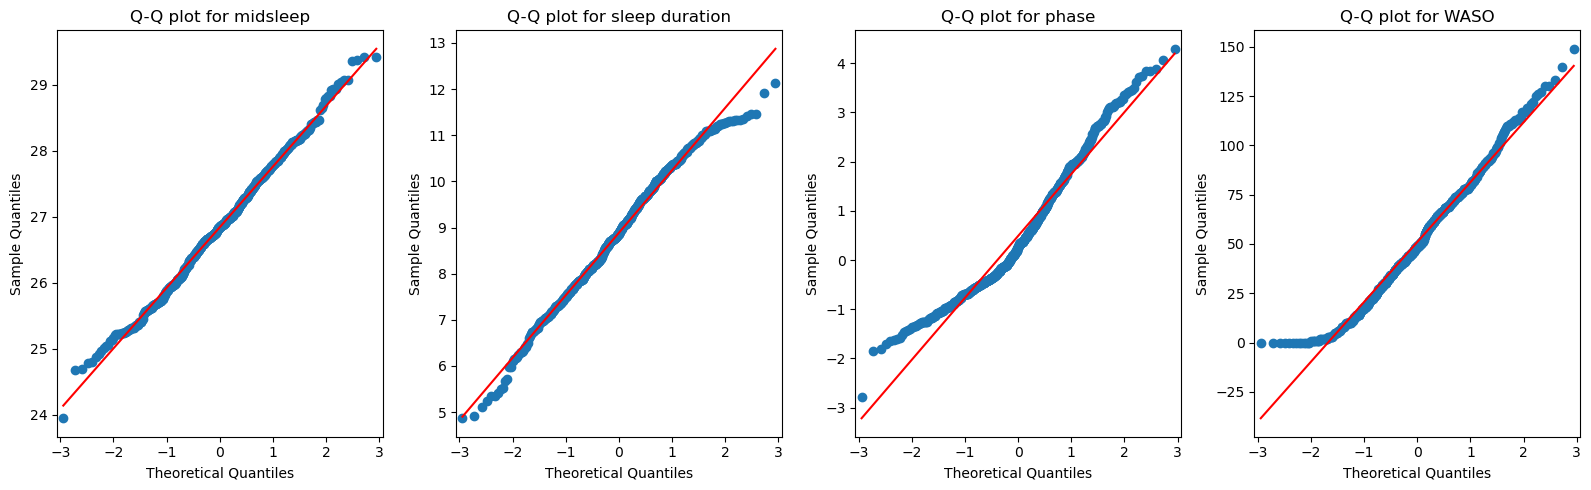

In [37]:
# Test normality by Q-Q plot
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

sm.qqplot(df['midsleep_h'].dropna(), line='s', ax=ax[0])
ax[0].set_title('Q-Q plot for midsleep')

sm.qqplot(df['sleep_duration'].dropna(), line='s', ax=ax[1])
ax[1].set_title('Q-Q plot for sleep duration')

sm.qqplot(df['phase'].dropna(), line='s', ax=ax[2])
ax[2].set_title('Q-Q plot for phase')

sm.qqplot(df['waso'].dropna(), line='s', ax=ax[3])
ax[3].set_title('Q-Q plot for WASO')

plt.tight_layout()
plt.show()


In [38]:
# test normality of the data using Shapiro-Wilk test 
# Null hipotesis(H0): data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration'])
shapiro_test_midsleep = stats.shapiro(df['midsleep_h'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal'])
shapiro_test_phase = stats.shapiro(df['phase'])
shapiro_test_waso = stats.shapiro(df['waso'].dropna())

In [39]:
shapiro_results_x = pd.DataFrame({
    'Variable': ['sleep_duration', 'midsleep_h', 'sleep_start_decimal', 'sleep_end_decimal', 'phase(sleepoffset-sunrise)', 'waso(min)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midsleep, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase, shapiro_test_waso]
})

In [172]:
shapiro_results_x

,Variable,Shapiro-Wilk test
0,sleep_duration,"(0.9895610753086119, 0.00023194931871214962)"
1,midsleep_h,"(0.9962122833382292, 0.14886313894264475)"
2,sleep_start_decimal,"(0.993453145281559, 0.008920581788049891)"
3,sleep_end_decimal,"(0.8888768503185855, 1.248926896293502e-20)"
4,phase(sleepoffset-sunrise),"(0.9604369493835675, 8.303522687642157e-12)"
5,waso(min),"(0.9801230593506521, 2.1932332024508105e-07)"


__Sleep-wake pattern between workdays and free days__

In [185]:
# descriptive statistics by location
df_grouped_weekdaytype = df.groupby('weekday_type').describe()

In [180]:
# compare variables between workdays and free days
# compare the variables between ITA and UK
ttest_midsleep_daytype = stats.ttest_ind(df[df['weekday_type'] == 'work days']['midsleep_h'], df[df['weekday_type'] == 'free days']['midsleep_h'])
ttest_duration_daytype = stats.ttest_ind(df[df['weekday_type'] == 'work days']['sleep_duration'], df[df['weekday_type'] == 'free days']['sleep_duration'])

utest_phase_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['phase'], df[df['weekday_type'] == 'free days']['phase'])
utest_start_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_start_decimal'], df[df['weekday_type'] == 'free days']['sleep_start_decimal'])
utest_end_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_end_decimal'], df[df['weekday_type'] == 'free days']['sleep_end_decimal'])
utest_waso_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['waso'].dropna(), df[df['weekday_type'] == 'free days']['waso'].dropna())

In [182]:
# print the results
print('T test results by day type')
print('T test midsleep:', ttest_midsleep_daytype)
print('T test duration:', ttest_duration_daytype)
print('U test results by day type')
print('U test phase:', utest_phase_daytype)
print('U test start:', utest_start_daytype)
print('U test end:', utest_end_daytype)
print('U test waso:', utest_waso_daytype)


T test results by day type
T test midsleep: TtestResult(statistic=-9.90026535134569, pvalue=1.5479699591399304e-21, df=613.0)
T test duration: TtestResult(statistic=-3.4084204583426163, pvalue=0.0006962430439879727, df=613.0)
U test results by day type
U test phase: MannwhitneyuResult(statistic=21651.0, pvalue=1.425425143284816e-15)
U test start: MannwhitneyuResult(statistic=28875.5, pvalue=1.788141106047635e-05)
U test end: MannwhitneyuResult(statistic=15925.0, pvalue=1.0221176037857113e-27)
U test waso: MannwhitneyuResult(statistic=29965.5, pvalue=0.0003694922994779455)


__Sleep-wake pattern between Uk and Italy__

In [44]:
# descriptive statistics by location
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [ ]:
# compare the variables between ITA and UK
ttest_midsleep_all_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midsleep_h'], df[df['location'] == 'UK']['midsleep_h'])
ttest_duration_loc = stats.ttest_ind(df[df['location'] == 'ITA']['sleep_duration'], df[df['location'] == 'UK']['sleep_duration'])

utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal'], df[df['location'] == 'UK']['sleep_start_decimal'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal'], df[df['location'] == 'UK']['sleep_end_decimal'])
utest_waso_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['waso'].dropna(), df[df['location'] == 'UK']['waso'].dropna())

In [183]:
# print the results
print('T test results by location')
print('Midsleep_all:', ttest_midsleep_all_loc)
print('Sleep_duration:', ttest_duration_loc)
print('U test results by location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Phase:', utest_phase_loc)
print('WASO:', utest_waso_loc)

T test results by location
Midsleep_all: TtestResult(statistic=-9.90026535134569, pvalue=1.5479699591399304e-21, df=613.0)
Sleep_duration: TtestResult(statistic=-3.4084204583426163, pvalue=0.0006962430439879727, df=613.0)
U test results by location
Sleep_onset: MannwhitneyuResult(statistic=28875.5, pvalue=1.788141106047635e-05)
Sleep_offset: MannwhitneyuResult(statistic=15925.0, pvalue=1.0221176037857113e-27)
Phase: MannwhitneyuResult(statistic=21651.0, pvalue=1.425425143284816e-15)
WASO: MannwhitneyuResult(statistic=29965.5, pvalue=0.0003694922994779455)


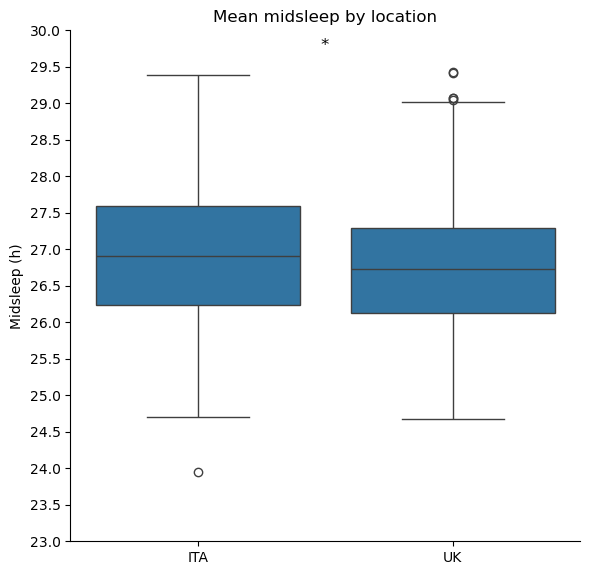

In [47]:
# plot the midpoint of sleep by location
plt.figure(figsize=(6, 6))
sns.boxplot(x='location', y='midsleep_h', data=df)
plt.title('Mean midsleep by location')
plt.suptitle('')  
plt.xlabel('')
plt.ylabel('Midsleep (h)')
plt.ylim(23, 30)
plt.annotate('*', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.5)) # gcd stands for 'get current axis'
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

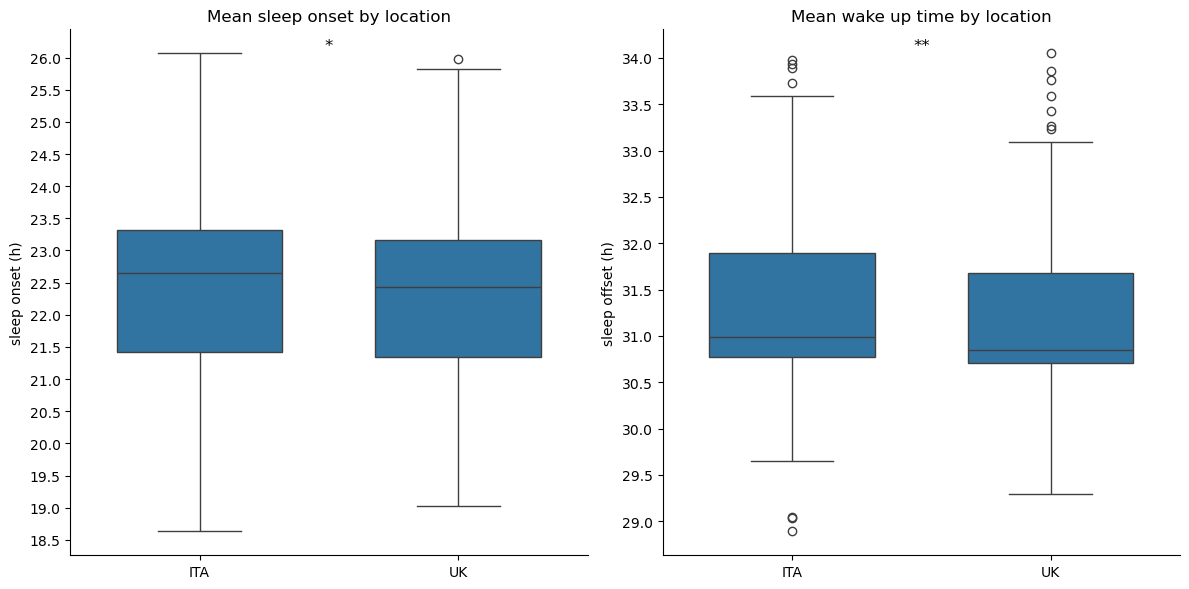

In [49]:
# plot the sleep onset and sleep offset by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal', data=df, gap=0.2)
plt.title('Mean sleep onset by location')
plt.xlabel('')
plt.ylabel('sleep onset (h)')
plt.annotate('*', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal', data=df, gap=0.2)
plt.title('Mean wake up time by location')
plt.xlabel('')
plt.ylabel('sleep offset (h)')
plt.annotate('**', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

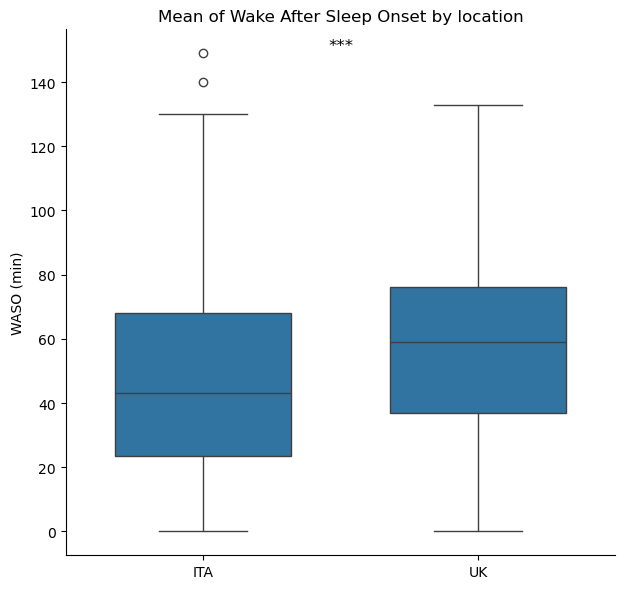

In [50]:
# plot the waso by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='waso', data=df, gap=0.2)
plt.title('Mean of Wake After Sleep Onset by location')
plt.xlabel('')
plt.ylabel('WASO (min)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
#plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

__Jet lag__

In [51]:
# drop the rows with missing values
jetlag_clean = weekly_means_jetlag['jet lag'].dropna()

In [52]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_clean)

In [53]:
print('Shapiro test result for jet lag:')
print(shapiro_test_jetlag)

Shapiro test result for jet lag:
ShapiroResult(statistic=0.9761586491415845, pvalue=0.07442219766639148)


In [54]:
# test the difference in jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag[weekly_means_jetlag['location'] == 'ITA']['jet lag'].dropna(), 
                               weekly_means_jetlag[weekly_means_jetlag['location'] == 'UK']['jet lag'].dropna())

In [55]:
print('T test result for jet lag by location:')
print(ttest_jetlag)

T test result for jet lag by location:
TtestResult(statistic=-1.1425594780867008, pvalue=0.2560929270530605, df=95.0)


__Season and sleep-wake pattern__

In [56]:
# remove NaN values from the columns and create a new dataframe
df1 = df.dropna(subset=['sleep_duration']) 
df2 = df.dropna(subset=['phase'])
df3 = df.dropna(subset=['waso'])

In [57]:
anova_ols_midsleep_season = ols('midsleep_h ~ C(season)', data=df).fit() # generate and fit the regression model
anova_results_midsleep = sm.stats.anova_lm(anova_ols_midsleep_season, typ=3) # fit the ANOVA model and get the results

In [58]:
print('ANOVA Result for midsleep:')
print(anova_results_midsleep)

ANOVA Result for midsleep:
                  sum_sq     df              F    PR(>F)
Intercept  163437.689747    1.0  193249.664757  0.000000
C(season)       1.700775    3.0       0.670335  0.570469
Residual      516.743088  611.0            NaN       NaN


In [59]:
anova_sleep_duration_season = ols('sleep_duration ~ C(season)', data=df1).fit()
anova_results_sleep_duration = sm.stats.anova_lm(anova_sleep_duration_season, typ=3)

print('ANOVA Result for sleep duration:')
print(anova_results_sleep_duration)

ANOVA Result for sleep duration:
                 sum_sq     df            F    PR(>F)
Intercept  16974.822223    1.0  9350.047222  0.000000
C(season)     18.616678    3.0     3.418137  0.017115
Residual    1109.258181  611.0          NaN       NaN


In [60]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df1['sleep_duration'], df1['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.3358 0.1426  -0.069 0.7406  False
Autumn Summer   0.2719  0.276  -0.118 0.6619  False
Autumn Winter    0.413  0.017  0.0531  0.773   True
Spring Summer  -0.0638 0.9841 -0.5213 0.3936  False
Spring Winter   0.0773 0.9675 -0.3549 0.5095  False
Summer Winter   0.1411 0.8209 -0.2772 0.5595  False
---------------------------------------------------


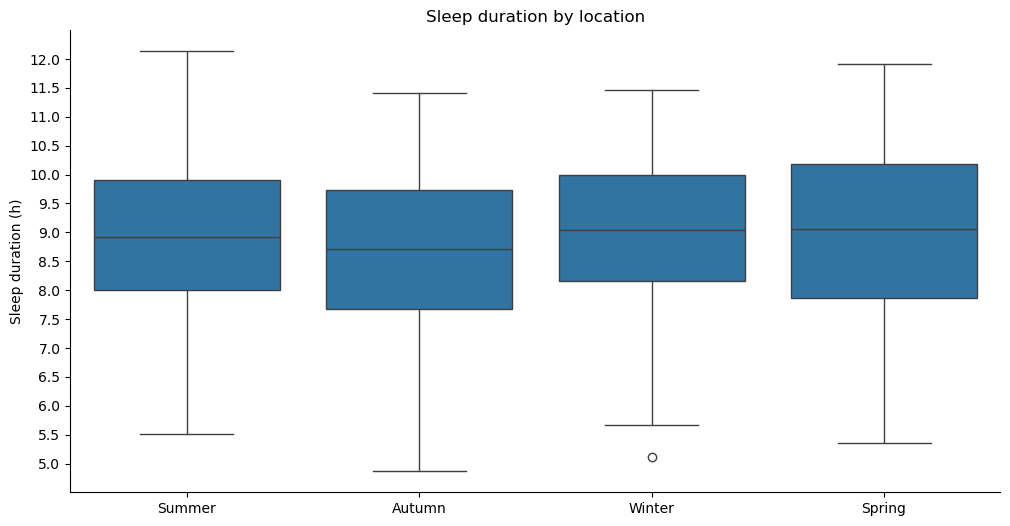

In [61]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_duration', data=df1)
plt.title('Sleep duration by location')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep duration (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [62]:
# perform a Kruskal-Wallis test to compare the phase, sleep end and waso between the seasons
kw_phase_season = stats.kruskal(df2[df2['season'] == 'Winter']['phase'], df2[df2['season'] == 'Spring']['phase'], 
                                df2[df2['season'] == 'Summer']['phase'], df2[df2['season'] == 'Autumn']['phase'])

kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal'], df[df['season'] == 'Spring']['sleep_start_decimal'], 
                              df[df['season'] == 'Summer']['sleep_start_decimal'], df[df['season'] == 'Autumn']['sleep_start_decimal'])

kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal'], df[df['season'] == 'Spring']['sleep_end_decimal'], 
                              df[df['season'] == 'Summer']['sleep_end_decimal'], df[df['season'] == 'Autumn']['sleep_end_decimal'])

kw_waso_season = stats.kruskal(df3[df3['season'] == 'Winter']['waso'], df3[df3['season'] == 'Spring']['waso'], 
                               df3[df3['season'] == 'Summer']['waso'], df3[df3['season'] == 'Autumn']['waso'])

print('Kruskal-Wallis test results for phase:')
print(kw_phase_season)
print('Kruskal-Wallis test results for sleep start:')
print(kw_start_season)
print('Kruskal-Wallis test results for sleep end:')
print(kw_end_season)
print('Kruskal-Wallis test results for waso:')  
print(kw_waso_season)

Kruskal-Wallis test results for phase:
KruskalResult(statistic=247.19749058480434, pvalue=2.6421372490868767e-53)
Kruskal-Wallis test results for sleep start:
KruskalResult(statistic=5.391606124487882, pvalue=0.14526744163228386)
Kruskal-Wallis test results for sleep end:
KruskalResult(statistic=5.204826002339254, pvalue=0.157398680883717)
Kruskal-Wallis test results for waso:
KruskalResult(statistic=1.871876294309124, pvalue=0.5994201122911456)


In [63]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df2['phase'], df2['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.6569    0.0   1.361  1.9529   True
Autumn Summer    1.651    0.0  1.3659  1.9362   True
Autumn Winter    0.074 0.8874 -0.1892  0.3372  False
Spring Summer  -0.0059    1.0 -0.3404  0.3286  False
Spring Winter  -1.5829    0.0  -1.899 -1.2669   True
Summer Winter  -1.5771    0.0  -1.883 -1.2712   True
----------------------------------------------------


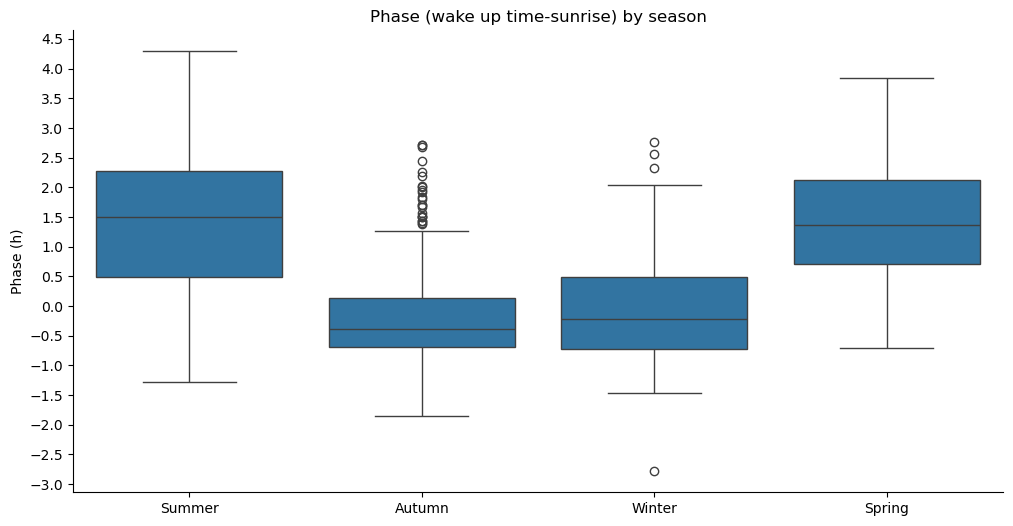

In [64]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by season')
plt.suptitle('')  # add space after the title
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__DST and sleep-wake pattern__

In [65]:
# t-test to compare the midpoint of sleep between DST and non-DST
ttest_midsleep_dst = stats.ttest_ind(df[df['DST_1'] == 0]['midsleep_h'], df[df['DST_1'] == 1]['midsleep_h'])
ttest_sleep_duration_dst = stats.ttest_ind(df1[df1['DST_1'] == 0]['sleep_duration'], df1[df1['DST_1'] == 1]['sleep_duration'])

utest_sleep_start_dst = stats.mannwhitneyu(df[df['DST_1'] == 0]['sleep_start_decimal'], df[df['DST_1'] == 1]['sleep_start_decimal'])
utest_sleep_end_dst = stats.mannwhitneyu(df[df['DST_1'] == 0]['sleep_end_decimal'], df[df['DST_1'] == 1]['sleep_end_decimal'])
utest_phase_dst = stats.mannwhitneyu(df2[df2['DST_1'] == 0]['phase'], df2[df2['DST_1'] == 1]['phase'])
utest_waso_dst = stats.mannwhitneyu(df3[df3['DST_1'] == 0]['waso'], df3[df3['DST_1'] == 1]['waso'])

In [66]:
print('T test result for the midsleep by DST:')
print(ttest_midsleep_dst)
print('T test result for the sleep duration by DST:')
print(ttest_sleep_duration_dst)
print('U test result for the sleep onset by DST:')
print(utest_sleep_start_dst)
print('U test result for the sleep offset by DST:')
print(utest_sleep_end_dst)
print('U test result for the phase by DST:')
print(utest_phase_dst)
print('U test result for the waso by DST:')
print(utest_waso_dst)

T test result for the midsleep by DST:
TtestResult(statistic=-0.9459234684199179, pvalue=0.34456032719754304, df=613.0)
T test result for the sleep duration by DST:
TtestResult(statistic=1.0610962627781768, pvalue=0.28906403183152274, df=613.0)
U test result for the sleep onset by DST:
MannwhitneyuResult(statistic=43672.0, pvalue=0.11834915303244424)
U test result for the sleep offset by DST:
MannwhitneyuResult(statistic=47955.0, pvalue=0.6999515400701236)
U test result for the phase by DST:
MannwhitneyuResult(statistic=23280.0, pvalue=2.366322061089594e-27)
U test result for the waso by DST:
MannwhitneyuResult(statistic=47271.5, pvalue=0.7781681710356353)


In [67]:
# mean and standard deviation of the phase by DST
df_grouped_dst = df.groupby('DST_1').agg({'phase': ['mean', 'std']})
df_grouped_dst = df_grouped_dst.reset_index()
df_grouped_dst.columns = ['DST', 'mean', 'std']

df_grouped_dst

,DST,mean,std
0,0,-0.093137,0.954441
1,1,1.004064,1.273328


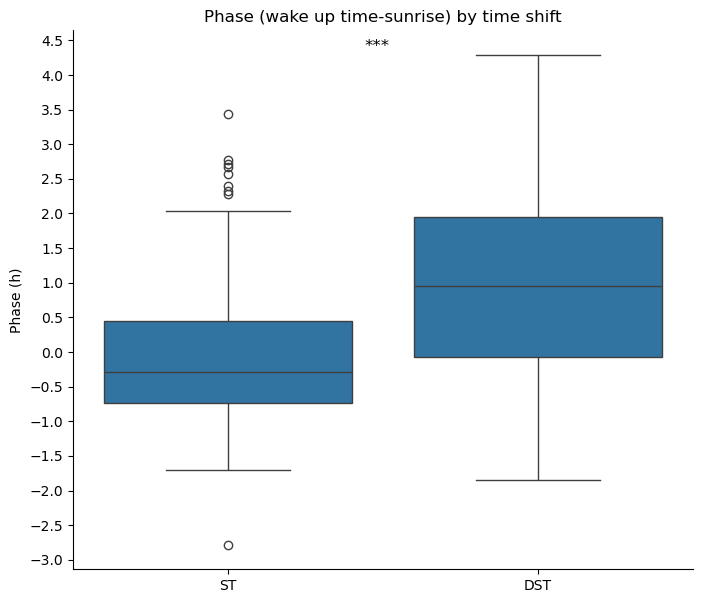

In [68]:
# phase (sleep offset - sunrise) by DST
plt.figure(figsize=(8, 7))
sns.boxplot(x='DST_1', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by time shift')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.xticks([0, 1], ['ST', 'DST'])
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('***', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__Photoperiod and sleep-wake pattern__

In [69]:
# correlation between sleep-wake variables and photoperiod
correlation1_test1 = stats.pearsonr(df['midsleep_h'], df['photoperiod'])
correlation1_test2 = stats.pearsonr(df_workdays['midsleep_h'], df_workdays['photoperiod'])
correlation1_test3 = stats.pearsonr(df_freedays['midsleep_h'], df_freedays['photoperiod'])
correlation1_test4 = stats.pearsonr(df2['sleep_duration'], df2['photoperiod'])

# correlation between sleep-wake variables and photoperiod using Spearman's rank correlation
correlation1_test5 = stats.spearmanr(df['sleep_start_decimal'], df['photoperiod'])
correlation1_test6 = stats.spearmanr(df['sleep_end_decimal'], df['photoperiod'])
correlation1_test7 = stats.spearmanr(df3['waso'], df3['photoperiod'])

In [70]:
# extract the coefficients and p-values from the correlation test results
correlation1_coeff = [correlation1_test1.statistic, correlation1_test2.statistic, correlation1_test3.statistic, 
                     correlation1_test4.statistic, correlation1_test5.statistic, correlation1_test6.statistic,
                     correlation1_test7.statistic]

p_values = [correlation1_test1.pvalue, correlation1_test2.pvalue, correlation1_test3.pvalue, 
            correlation1_test4.pvalue, correlation1_test5.pvalue, correlation1_test6.pvalue,
            correlation1_test7.pvalue]

In [71]:
# create a DataFrame with the results
correlation1_results = pd.DataFrame({
    'Variables': ['midsleep vs photoperiod', 'midsleep (w) vs photoperiod', 'midsleep (f) vs photoperiod', 
                  'sleep duration vs photoperiod', 'sleep onset vs photoperiod', 'sleep offset vs photoperiod', 'WASO(min) vs photoperiod'],
    'Coefficient': correlation1_coeff,
    'P-value': p_values
})

correlation1_results

,Variables,Coefficient,P-value
0,midsleep vs photoperiod,-0.017377,0.667134
1,midsleep (w) vs photoperiod,-0.011036,0.815604
2,midsleep (f) vs photoperiod,-0.029854,0.702599
3,sleep duration vs photoperiod,0.027991,0.488392
4,sleep onset vs photoperiod,-0.000874,0.982736
5,sleep offset vs photoperiod,-0.022049,0.585238
6,WASO(min) vs photoperiod,0.027864,0.491429


In [72]:
# correlation between sleep-wake variables and photoperiod
correlation2_test1 = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
correlation2_test2 = stats.pearsonr(df_workdays['midsleep_h_UTC'], df_workdays['photoperiod'])
correlation2_test3 = stats.pearsonr(df_freedays['midsleep_h_UTC'], df_freedays['photoperiod'])
correlation2_test4 = stats.pearsonr(df2['sleep_duration'], df2['photoperiod'])

# correlation between sleep-wake variables and photoperiod using Spearman's rank correlation
correlation2_test5 = stats.spearmanr(df['sleep_start_decimal_UTC'], df['photoperiod'])
correlation2_test6 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])
correlation2_test7 = stats.spearmanr(df3['waso'], df3['photoperiod'])

In [73]:
# extract the coefficients and p-values from the correlation test results
correlation2_coeff = [correlation2_test1.statistic, correlation2_test2.statistic, correlation2_test3.statistic, 
                     correlation2_test4.statistic, correlation2_test5.statistic, correlation2_test6.statistic,
                     correlation2_test7.statistic]

p_values = [correlation2_test1.pvalue, correlation2_test2.pvalue, correlation2_test3.pvalue, 
            correlation2_test4.pvalue, correlation2_test5.pvalue, correlation2_test6.pvalue,
            correlation2_test7.pvalue]

In [74]:
# create a DataFrame with the results
correlation2_results = pd.DataFrame({
    'Variables': ['midsleep vs photoperiod', 'midsleep (w) vs photoperiod', 'midsleep (f) vs photoperiod', 
                  'sleep duration vs photoperiod', 'sleep onset vs photoperiod', 'sleep offset vs photoperiod', 'WASO(min) vs photoperiod'],
    'Coefficient': correlation2_coeff,
    'P-value': p_values
})

correlation2_results

,Variables,Coefficient,P-value
0,midsleep vs photoperiod,-0.380484,1.280424e-22
1,midsleep (w) vs photoperiod,-0.393202,4.723620e-18
2,midsleep (f) vs photoperiod,-0.406591,5.459711e-08
3,sleep duration vs photoperiod,0.027991,4.883925e-01
4,sleep onset vs photoperiod,-0.302571,1.737304e-14
5,sleep offset vs photoperiod,-0.389193,1.122851e-23
6,WASO(min) vs photoperiod,0.027864,4.914285e-01


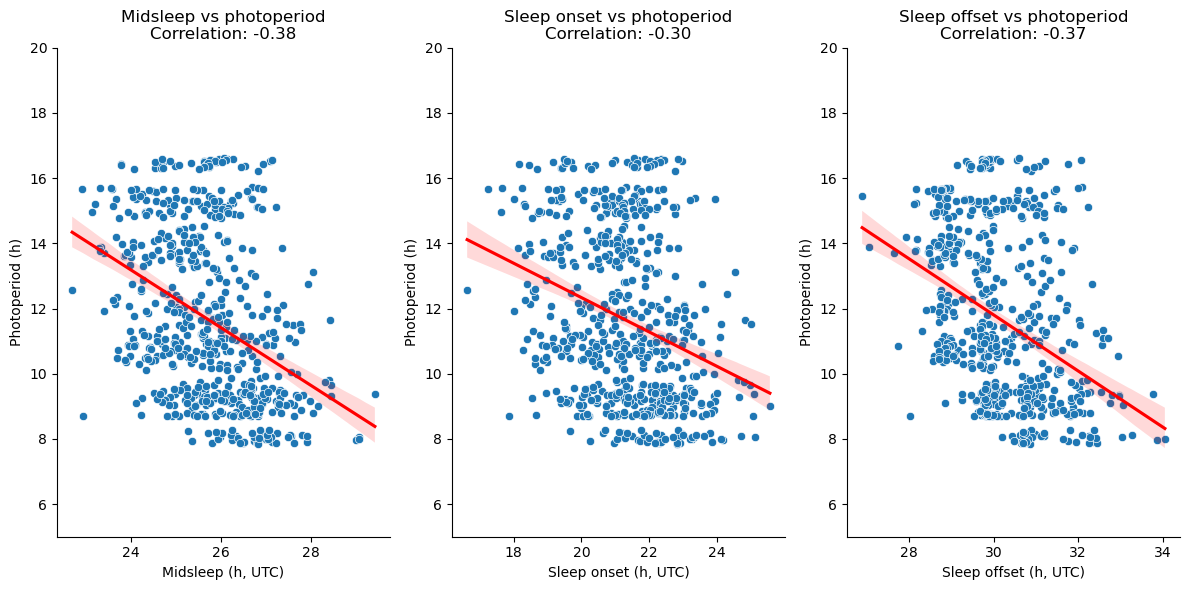

In [75]:
# plot the correlation between the midpoint of sleep and photoperiod, for all the data, work days and free days
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_all, _ = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
plt.title(f'Midsleep vs photoperiod\nCorrelation: {corr_all:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.subplot(1, 3, 2)
sns.scatterplot(x='sleep_start_decimal_UTC', y='photoperiod', data=df)
sns.regplot(x='sleep_start_decimal_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_free, _ = stats.pearsonr(df['sleep_start_decimal_UTC'], df['photoperiod'])
plt.title(f'Sleep onset vs photoperiod\nCorrelation: {corr_free:.2f}')
plt.xlabel('Sleep onset (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.subplot(1, 3, 3)
sns.scatterplot(x='sleep_end_decimal_UTC', y='photoperiod', data=df)
sns.regplot(x='sleep_end_decimal_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_offset, _ = stats.pearsonr(df['sleep_end_decimal_UTC'], df['photoperiod'])
plt.title(f'Sleep offset vs photoperiod\nCorrelation: {corr_offset:.2f}')
plt.xlabel('Sleep offset (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.tight_layout()
plt.show()

__Weekly IV, IS and RA__

In [76]:
# load the datasets required for the analysis
weekly_values = pd.read_csv(fpath + '\\2.0_weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag

In [77]:
# split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [78]:
# convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [79]:
# merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

In [80]:
merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag,location
0,15,2023-04-12 to 2023-04-18,NaN,0.024172,NaN,2023-04-12,2023-04-18,27.437500,26.821875,0.615625,ITA
1,32,2023-08-09 to 2023-08-15,NaN,0.048807,NaN,2023-08-09,2023-08-15,26.600000,27.093333,-0.493333,ITA
2,31,2024-07-31 to 2024-08-06,NaN,0.027033,0.949047,2024-07-31,2024-08-06,28.460417,26.690625,1.769792,ITA
3,33,2023-08-16 to 2023-08-22,NaN,0.053677,0.948446,2023-08-16,2023-08-22,27.397917,26.226667,1.171250,UK
4,9,2023-03-01 to 2023-03-07,NaN,0.040270,0.953698,2023-03-01,2023-03-07,27.406250,26.628333,0.777917,ITA


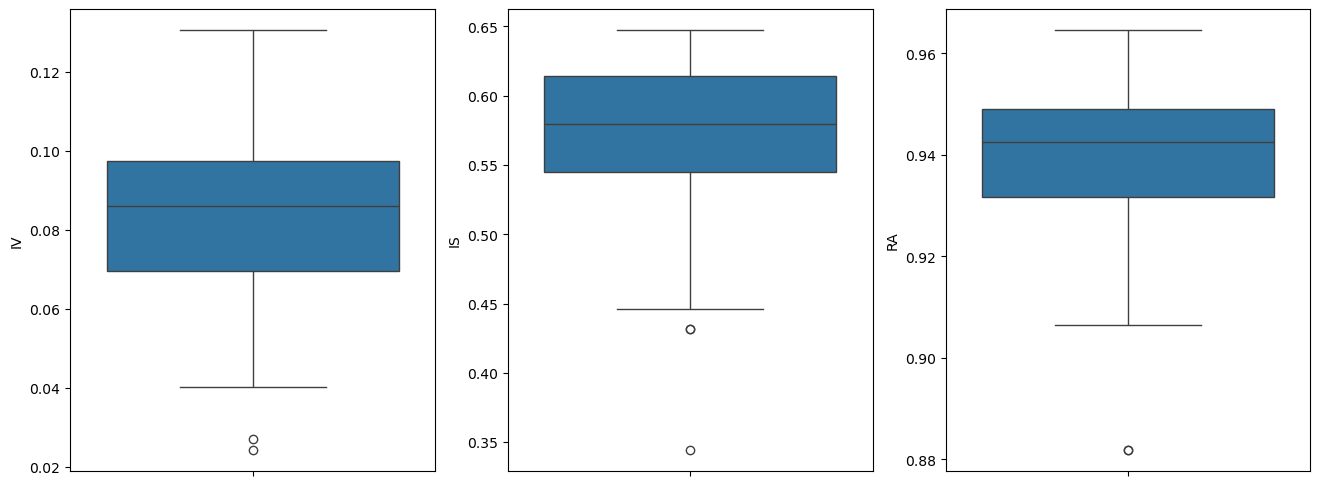

In [81]:
# box plot to verify the outliers in IV, IS, and RA
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
sns.boxplot(data=merged_data['IV'], ax=ax[0])
sns.boxplot(data=merged_data['IS'], ax=ax[1])
sns.boxplot(data=merged_data['RA'], ax=ax[2])
plt.show()

In [82]:
# summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()

summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       53.0  0.080466  0.022129  0.024172  0.067942  0.082638  0.093785   
UK        36.0  0.088307  0.017596  0.053677  0.075609  0.087177  0.098561   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  48.0  0.574327  ...  0.614767  0.647358  50.0  0.940170   
UK        0.130562  34.0  0.567904  ...  0.613489  0.645810  34.0  0.937674   

                                                                     
              std       min       25%       50%       75%       max  
location                                                             
ITA       0.01533  0.881815  0.931972  0.942574  0.950680  0.964584  
UK        0.01699  0.881815  0.930985  0.942574  0.947245  0.962952  

[2 rows x 24 columns]

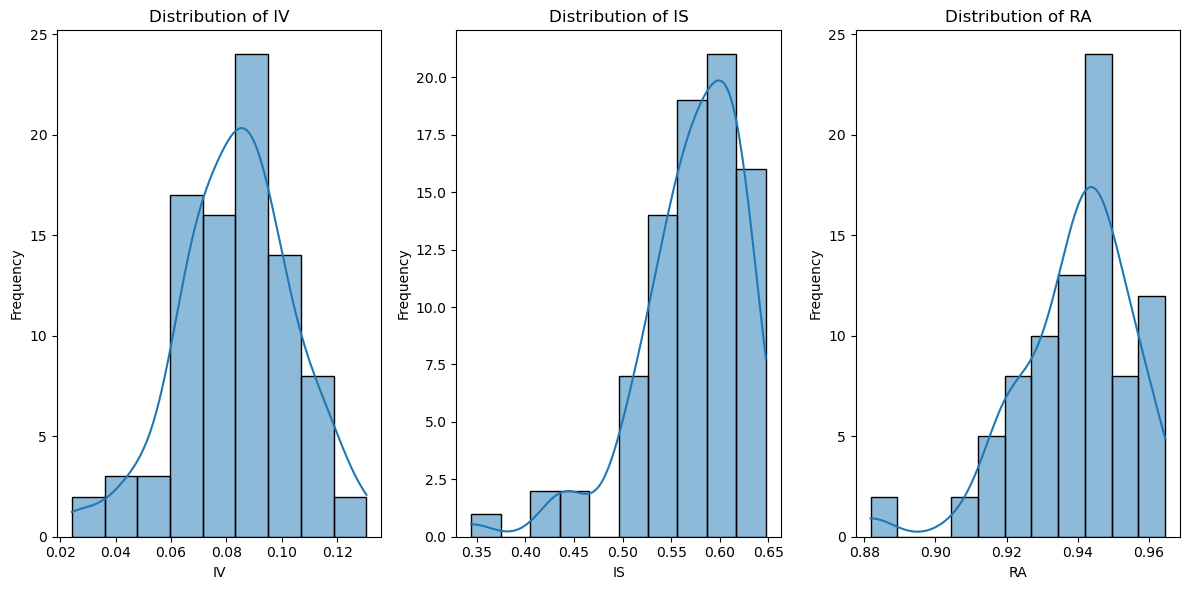

In [83]:
# distribution of IV, IS, and RA
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title('Distribution of IV')
plt.xlabel('IV')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title('Distribution of RA')
plt.xlabel('RA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [84]:
# compare the variables between ITA and UK
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [85]:
print('Test results for IV by location:', iv_ttest)
print('Test results for IS by location:', is_utest)
print('Test results for RA by location:', ra_utest)

Test results for IV by location: TtestResult(statistic=-1.7772445658632352, pvalue=0.07902284498496115, df=87.0)
Test results for IS by location: MannwhitneyuResult(statistic=869.5, pvalue=0.6178431739272754)
Test results for RA by location: MannwhitneyuResult(statistic=916.5, pvalue=0.5474926482394891)


------------------------

__Sleep-wake patterns over time__

In [86]:
# filter df to have only day_after_flight 1,2,8,9
df_flight1 = df[df['day_after_flight'].isin([1, 2, 8, 9])]

In [87]:
# new column with the day after flight day 1 and 2 as '0' and day 8 and 9 as '1'
df_flight1['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight1['day_after_flight'].isin([1, 2]), '0', '1')

C:\Users\gg00642\AppData\Local\Temp\ipykernel_15384\3185984710.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_flight1['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight1['day_after_flight'].isin([1, 2]), '0', '1')


In [88]:
# rename df_flight1['day_after_flight_group(0=day1&2;1=day8&9)']
df_flight1 = df_flight1.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})

_Sleep onset_

In [89]:
model1 = smf.mixedlm('sleep_start_decimal ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model1.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sleep_start_decimal
No. Observations: 615     Method:             REML               
No. Groups:       45      Scale:              1.7178             
Min. group size:  1       Log-Likelihood:     -1056.4241         
Max. group size:  46      Converged:          Yes                
Mean group size:  13.7                                           
------------------------------------------------------------------
                  Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept         22.326     0.103  216.598  0.000  22.124  22.528
day_after_flight   0.006     0.009    0.650  0.516  -0.012   0.023
Group Var          0.101     0.039                                



In [90]:
model2 = smf.mixedlm('sleep_start_decimal ~ day_after_flight + location + location*day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                   Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    sleep_start_decimal
No. Observations:     615        Method:                REML               
No. Groups:           45         Scale:                 1.7033             
Min. group size:      1          Log-Likelihood:        -1057.2202         
Max. group size:      46         Converged:             Yes                
Mean group size:      13.7                                                 
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       22.338    0.135 165.361 0.000 22.073 22.603
location[T.UK]                   0.187    0.224   0.835 0.404 -0.252  0.627
day_after_flight                 0.013    0.010   1.331 0.183 -0.006  0.032
location[T.UK]:day_after_flight

In [91]:
# shapiro-wilk test for sleep_start_decimal
shapiro_test_sleep_start = stats.shapiro(df_flight1['sleep_start_decimal'])

shapiro_test_sleep_start

ShapiroResult(statistic=0.9934356410184709, pvalue=0.6782644327853187)

In [92]:
ttest_start_days = stats.ttest_ind(df_flight1[df_flight1['day_after_flight_group'] == '0']['sleep_start_decimal'], df_flight1[df_flight1['day_after_flight_group'] == '1']['sleep_start_decimal'])

ttest_start_days

TtestResult(statistic=2.411119774898022, pvalue=0.017036494448744412, df=160.0)

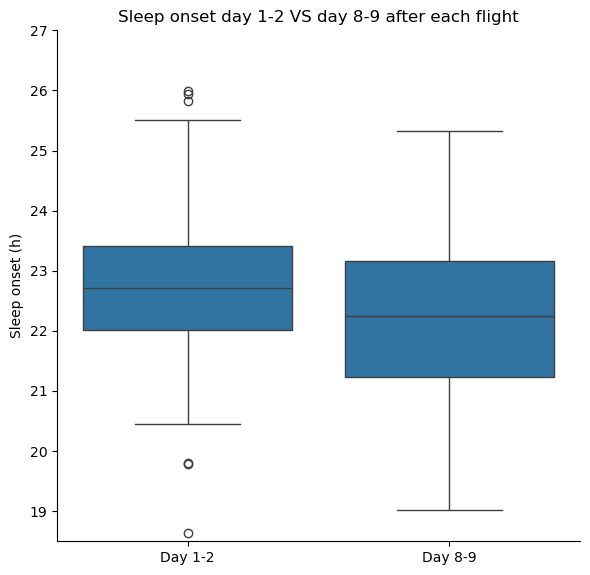

In [93]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='sleep_start_decimal', data=df_flight1)
plt.title('Sleep onset day 1-2 VS day 8-9 after each flight')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep onset (h)')
plt.xlabel('')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(18.5, 27)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

In [94]:
# Fit the factorial ANOVA model
model4 = ols('sleep_start_decimal ~ C(location) * C(day_after_flight_group)', data=df_flight1).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model4, typ=2)

print(anova_results)

                                           sum_sq     df         F    PR(>F)
C(location)                              0.286987    1.0  0.157840  0.691689
C(day_after_flight_group)               10.641207    1.0  5.852571  0.016690
C(location):C(day_after_flight_group)    4.365013    1.0  2.400719  0.123280
Residual                               287.277275  158.0       NaN       NaN


In [95]:
# Fit a mixed-effects model with random intercepts and slopes for location and flight_id
model5 = smf.mixedlm('sleep_start_decimal ~ C(location) + photoperiod + C(location)*photoperiod + day_after_flight + C(location)*day_after_flight',
                      data=df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model5.summary())

                    Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     sleep_start_decimal
No. Observations:     615         Method:                 REML               
No. Groups:           45          Scale:                  1.7075             
Min. group size:      1           Log-Likelihood:         -1059.6295         
Max. group size:      46          Converged:              Yes                
Mean group size:      13.7                                                   
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          21.854    0.510 42.851 0.000 20.854 22.853
C(location)[T.UK]                   1.472    0.679  2.169 0.030  0.142  2.802
photoperiod                         0.040    0.041  0.973 0.330 -0.041  0.121
C(loca

In [96]:
coef_onset = pd.DataFrame({'coef': model5.params.values, 'p-value': model5.pvalues.values, '0.025': model5.conf_int()[0], '0.975': model5.conf_int()[1]})
coef_onset

,coef,p-value,0.025,0.975
Intercept,21.853621,0.000000,20.854058,22.853185
C(location)[T.UK],1.472214,0.030046,0.142181,2.802246
photoperiod,0.040030,0.330359,-0.040573,0.120633
C(location)[T.UK]:photoperiod,-0.108052,0.044854,-0.213623,-0.002481
day_after_flight,0.014689,0.129570,-0.004304,0.033683
C(location)[T.UK]:day_after_flight,-0.052659,0.020725,-0.097282,-0.008037
Group Var,0.049372,0.091260,-0.007928,0.106672


In [97]:
#drop non significant variables
coef_onset = coef_onset.drop('Intercept')
coef_onset = coef_onset.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_15384\1928092645.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location [T.UK]', 'Photoperiod', 'Location [T.UK]*Photoperiod','Days after flight', 'Location [T.UK]*Days after flight'], fontsize=9)


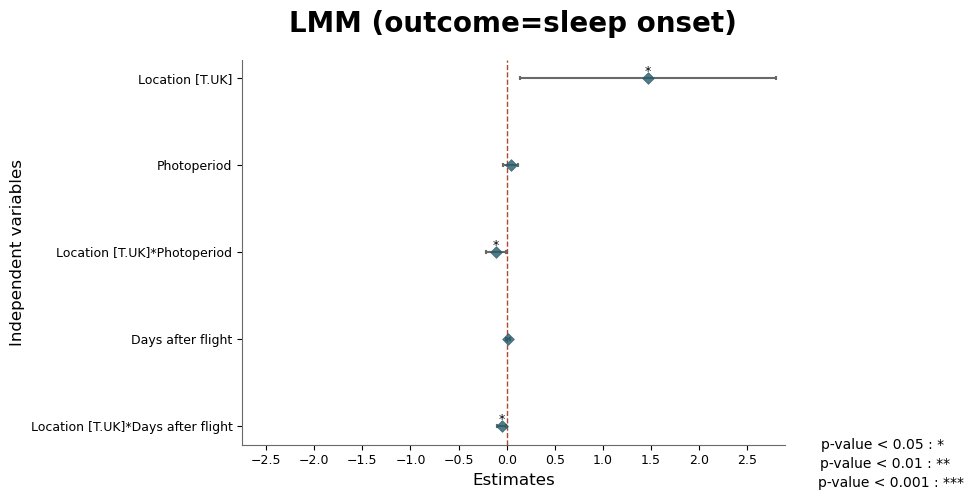

In [98]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_onset.index, data=coef_onset, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_onset.shape[0]):
    plt.plot([coef_onset['0.025'].iloc[i], coef_onset['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_onset['0.025'].iloc[i], coef_onset['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_onset['0.975'].iloc[i], coef_onset['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_onset.shape[0]):
    if coef_onset['p-value'].iloc[i] < 0.001:
        plt.text(coef_onset['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_onset['p-value'].iloc[i] < 0.01:
        plt.text(coef_onset['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_onset['p-value'].iloc[i] < 0.055:
        plt.text(coef_onset['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=sleep onset)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.89)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location [T.UK]', 'Photoperiod', 'Location [T.UK]*Photoperiod','Days after flight', 'Location [T.UK]*Days after flight'], fontsize=9)

plt.show()

<Figure size 800x600 with 0 Axes>

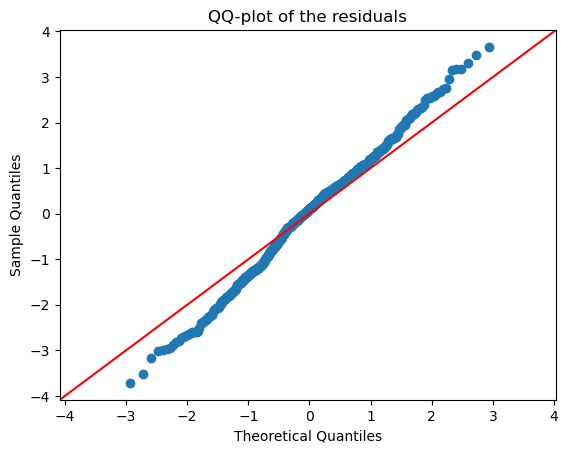

In [99]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [100]:
residualsY = model5.resid 
predictedY = model5.fittedvalues

In [101]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model5.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 3.074540236421031, p-value: 0.6884949494667297
The residuals are homoscedastic (fail to reject H0).


In [102]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

Durbin-Watson test: 1.9176825786749971


In [103]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

In [104]:
#extract from df sunrise and sunset times for both the UK and Italy and create a new dataframe df_daylight
df_daylight1 = pd.read_excel(fpath + '\\1.0_sunset_sunrise_UTC.xlsx', sheet_name='Sheet2')

In [105]:
def adjust_value(row):
    timeshift = row['DST(0=ST)']
    
    if timeshift == 1:
                return row['sunrise (uk), hours'] + 1, row['sunset (uk), hours'] + 1, row['sunrise (ita), hours'] + 2, row['sunset (ita), hours'] + 2
    elif timeshift == 0:
                return row['sunrise (uk), hours'] - 0, row['sunset (uk), hours'] - 0, row['sunrise (ita), hours'] + 1, row['sunset (ita), hours'] + 1
    
    return row['sunrise (uk), hours'], row['sunset (uk), hours'], row['sunrise (ita), hours'], row['sunset (ita), hours']

df_daylight1[['sunrise (uk), hours_adjust', 'sunset (uk), hours_adjust', 'sunrise (ita), hours_adjust', 'sunset (ita), hours_adjust']] = df_daylight1.apply(adjust_value, axis=1, result_type='expand')

In [106]:
# Function to convert hours to hh:mm format
def hours_to_hhmm(x, pos):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return f'{hours:02d}:{minutes:02d}'

In [107]:
#add 24 hours to the sleep_start_decimal and sleep_end_decimal
df['sleep_end_decimal_plot'] = df['sleep_end_decimal'] - 24
df['sleep_end_decimal_UTC_plot'] = df['sleep_end_decimal_UTC'] - 24

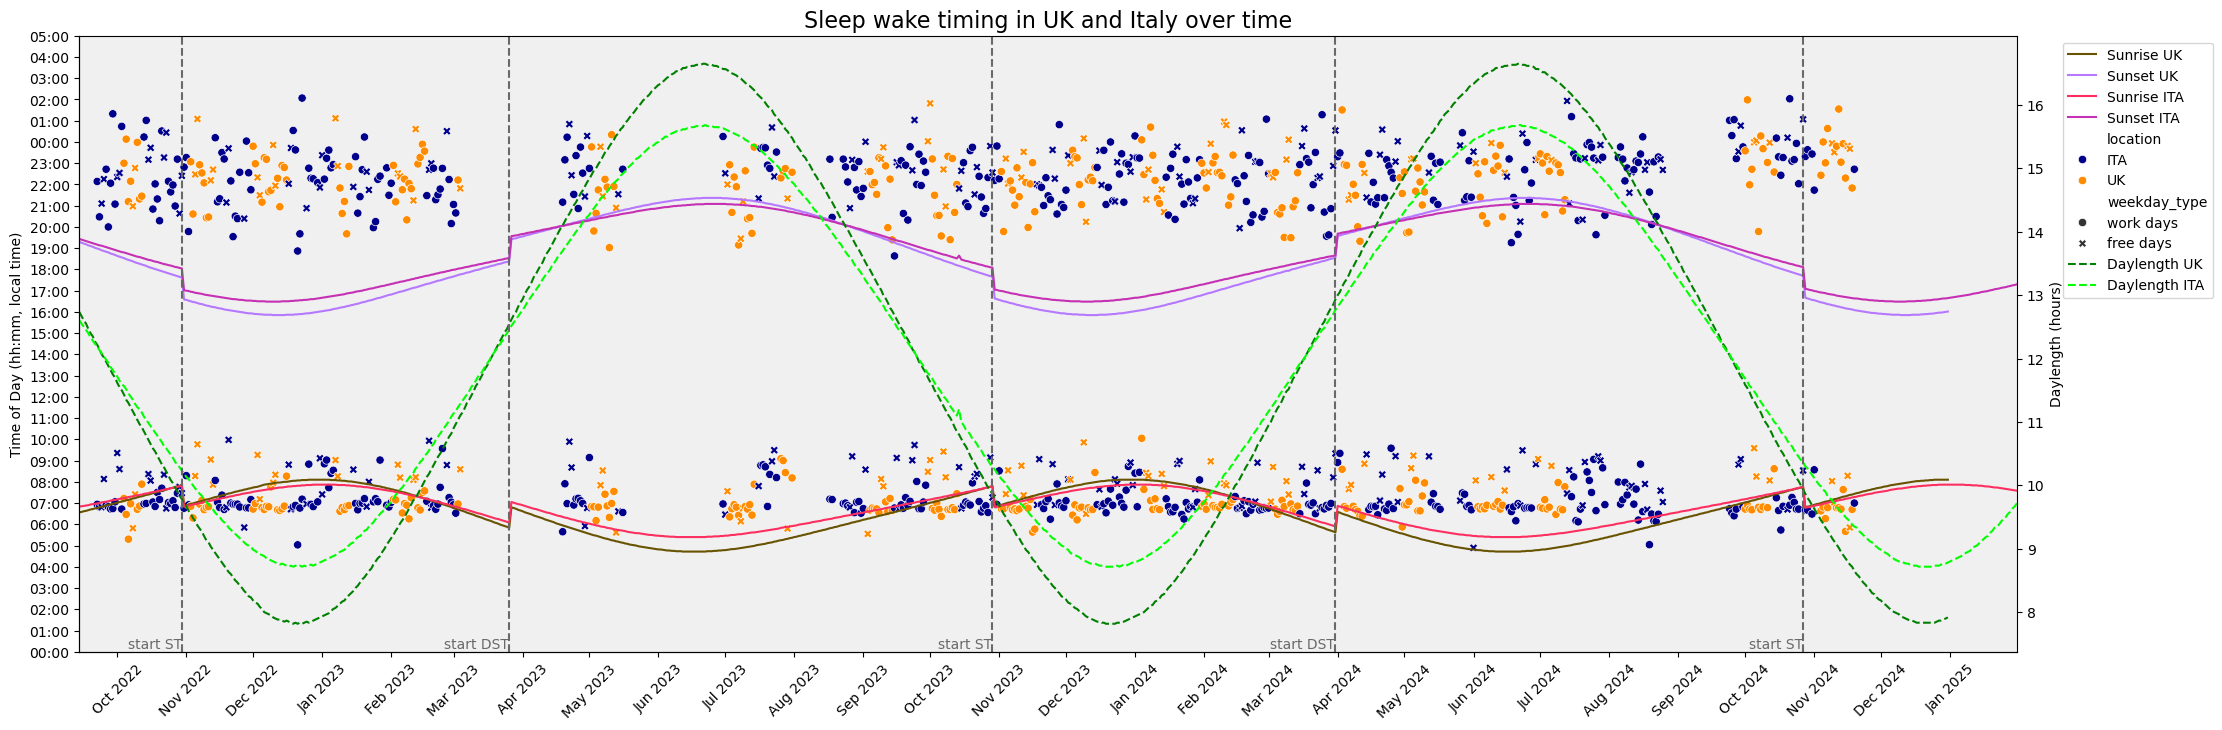

In [209]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# UK sunrise and sunset
sns.lineplot(x='date', y='sunrise (uk), hours_adjust', data=df_daylight1, label='Sunrise UK', color='#675300', ax=ax1)
sns.lineplot(x='date', y='sunset (uk), hours_adjust', data=df_daylight1, label='Sunset UK', color='#b578ff', ax=ax1)

# ITA sunrise and sunset
sns.lineplot(x='date', y='sunrise (ita), hours_adjust', data=df_daylight1, label='Sunrise ITA', color='#fd2f60', ax=ax1)
sns.lineplot(x='date', y='sunset (ita), hours_adjust', data=df_daylight1, label='Sunset ITA', color='#c530b4', ax=ax1)

# sleep onset and offset
sns.scatterplot(x='date', y='sleep_start_decimal', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)
sns.scatterplot(x='date', y='sleep_end_decimal_plot', hue='location', data=df, style='weekday_type', palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Add a third y-axis for daylight length
ax2 = ax1.twinx()
sns.lineplot(x='date', y=df_daylight1['sunset (uk), hours_adjust'] - df_daylight1['sunrise (uk), hours_adjust'], data=df_daylight1, ax=ax2, label='Daylength UK', color='green', linestyle='--')
sns.lineplot(x='date', y=df_daylight1['sunset (ita), hours_adjust'] - df_daylight1['sunrise (ita), hours_adjust'], data=df_daylight1, ax=ax2, label='Daylength ITA', color='lime', linestyle='--')

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Time of Day (hh:mm, local time)')
ax1.set_title('Sleep wake timing in UK and Italy over time', fontsize=16)
ax2.set_ylabel('Daylength (hours)')

# Remove space y axis and plot
plt.gca().margins(x=0)

# Format y-axis to hh:mm
ax1.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# 3 hours interval on y-axis
ax1.set_yticks(range(0, 30, 1))
ax1.set_yticklabels([hours_to_hhmm(i % 24, None) for i in range(0, 30, 1)])

#set ax2 y interval
ax2.set_yticks(range(8, 17, 1))

# Remove space y axis and plot
ax1.margins(x=0)

# Adding legend to the right of the plot
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.get_legend().remove()

# Set x-axis major locator of ax1
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

#plt.xlim(pd.to_datetime('2024-08-02'), pd.to_datetime('2024-12-03'))

plt.show()

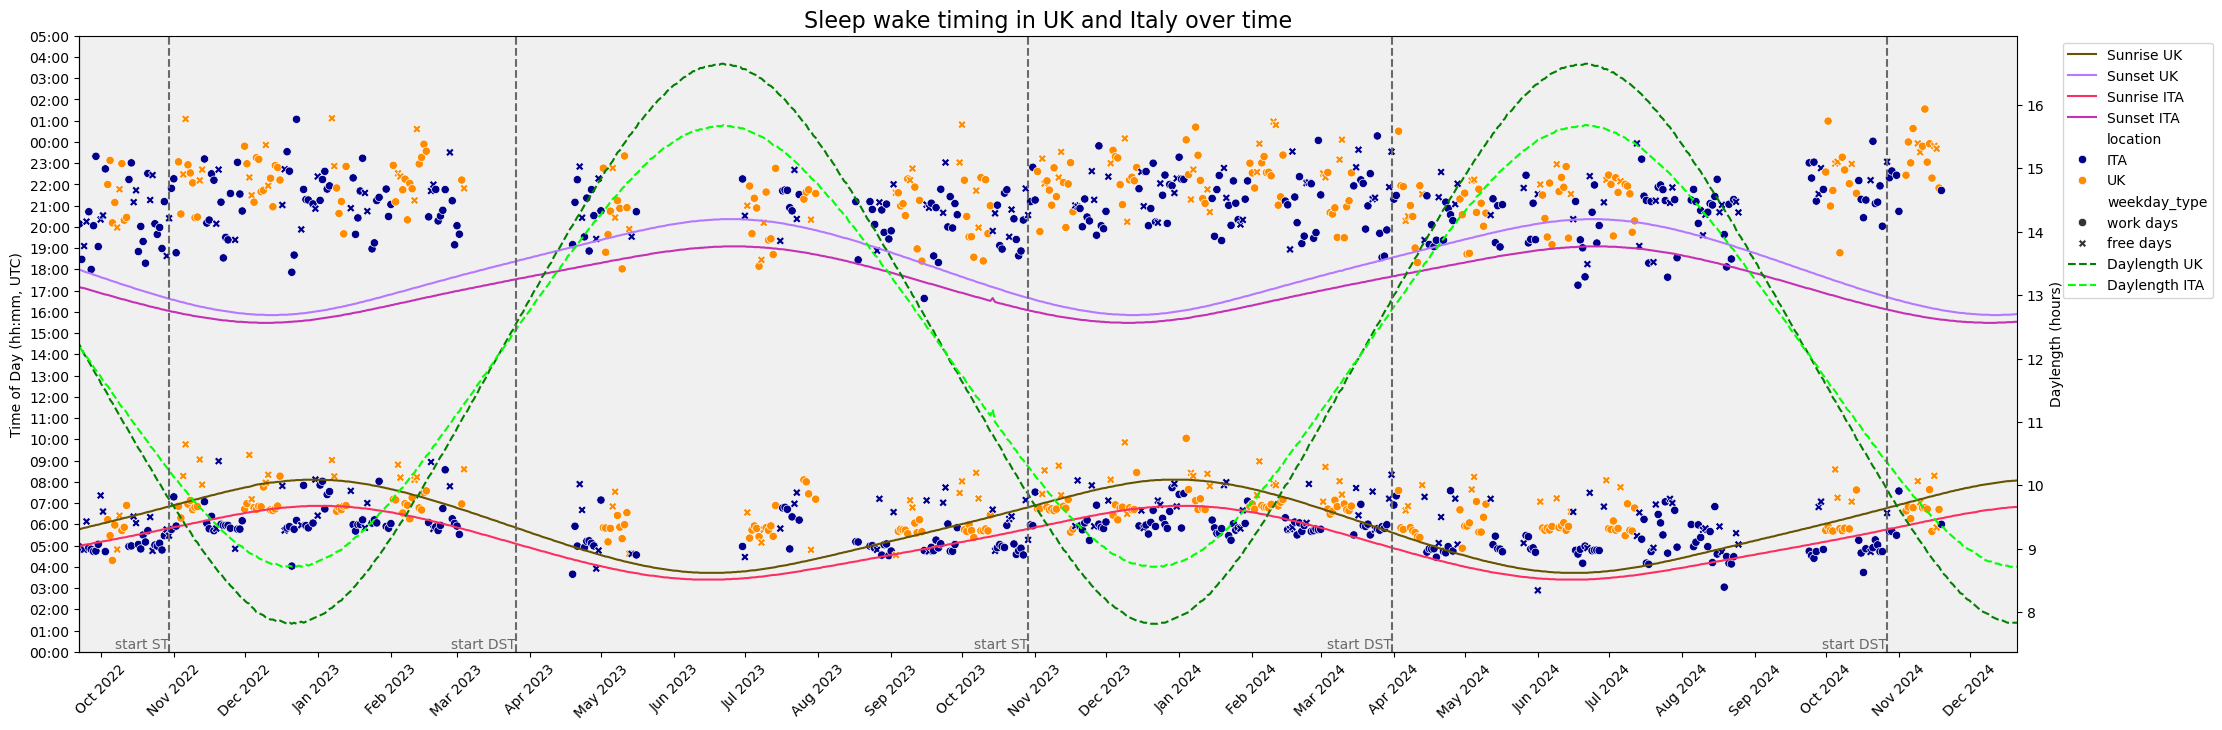

In [109]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# UK sunrise and sunset
sns.lineplot(x='date', y='sunrise (uk), hours', data=df_daylight1, label='Sunrise UK', color='#675300', ax=ax1)
sns.lineplot(x='date', y='sunset (uk), hours', data=df_daylight1, label='Sunset UK', color='#b578ff', ax=ax1)

# ITA sunrise and sunset
sns.lineplot(x='date', y='sunrise (ita), hours', data=df_daylight1, label='Sunrise ITA', color='#fd2f60', ax=ax1)
sns.lineplot(x='date', y='sunset (ita), hours', data=df_daylight1, label='Sunset ITA', color='#c530b4', ax=ax1)

# sleep onset and offset
sns.scatterplot(x='date', y='sleep_start_decimal_UTC', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)
sns.scatterplot(x='date', y='sleep_end_decimal_UTC_plot', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Add a third y-axis for daylight length
ax2 = ax1.twinx()
sns.lineplot(x='date', y=df_daylight1['sunset (uk), hours'] - df_daylight1['sunrise (uk), hours'], data=df_daylight1, ax=ax2, label='Daylength UK', color='green', linestyle='--')
sns.lineplot(x='date', y=df_daylight1['sunset (ita), hours'] - df_daylight1['sunrise (ita), hours'], data=df_daylight1, ax=ax2, label='Daylength ITA', color='lime', linestyle='--')

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Time of Day (hh:mm, UTC)')
ax1.set_title('Sleep wake timing in UK and Italy over time', fontsize=16)
ax2.set_ylabel('Daylength (hours)')

# Remove space y axis and plot
plt.gca().margins(x=0)

# Format y-axis to hh:mm
ax1.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# 3 hours interval on y-axis
ax1.set_yticks(range(0, 30, 1))
ax1.set_yticklabels([hours_to_hhmm(i % 24, None) for i in range(0, 30, 1)])

#set ax2 y interval
ax2.set_yticks(range(8, 17, 1))

# Remove space y axis and plot
ax1.margins(x=0)

# Adding legend to the right of the plot
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.get_legend().remove()

# Set x-axis major locator of ax1
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start DST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-22'), pd.to_datetime('2024-12-21'))

plt.show()

_Midsleep_

In [110]:
# Order the data by date
df = df.sort_values(by='date')
df_flight1 = df_flight1.sort_values(by='date')

In [111]:
model1 = smf.mixedlm('midsleep_h ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  midsleep_h
No. Observations:   615      Method:              REML      
No. Groups:         45       Scale:               0.8167    
Min. group size:    1        Log-Likelihood:      -824.0581 
Max. group size:    46       Converged:           Yes       
Mean group size:    13.7                                    
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept        26.802    0.067 397.381 0.000 26.670 26.934
day_after_flight  0.004    0.006   0.580 0.562 -0.008  0.015
Group Var         0.027    0.022                            



In [112]:
model2 = smf.mixedlm('midsleep_h ~ day_after_flight + location + location*day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                   Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       midsleep_h
No. Observations:        615           Method:                   REML      
No. Groups:              45            Scale:                    0.8124    
Min. group size:         1             Log-Likelihood:           -824.9566 
Max. group size:         46            Converged:                Yes       
Mean group size:         13.7                                              
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       26.830    0.085 314.568 0.000 26.663 26.998
location[T.UK]                   0.088    0.145   0.608 0.543 -0.196  0.373
day_after_flight                 0.008    0.006   1.204 0.229 -0.005  0.020
location[T.UK]:day_after_flight

In [113]:
shapiro_test_midsleep = stats.shapiro(df_flight1['midsleep_h'])

shapiro_test_midsleep

ShapiroResult(statistic=0.9936607844195883, pvalue=0.7061901519823246)

In [114]:
ttest_midsleep_days = stats.ttest_ind(df_flight1[df_flight1['day_after_flight_group'] == '0']['midsleep_h'], df_flight1[df_flight1['day_after_flight_group'] == '1']['midsleep_h'])

ttest_midsleep_days

TtestResult(statistic=2.321330718284362, pvalue=0.021530489694958937, df=160.0)

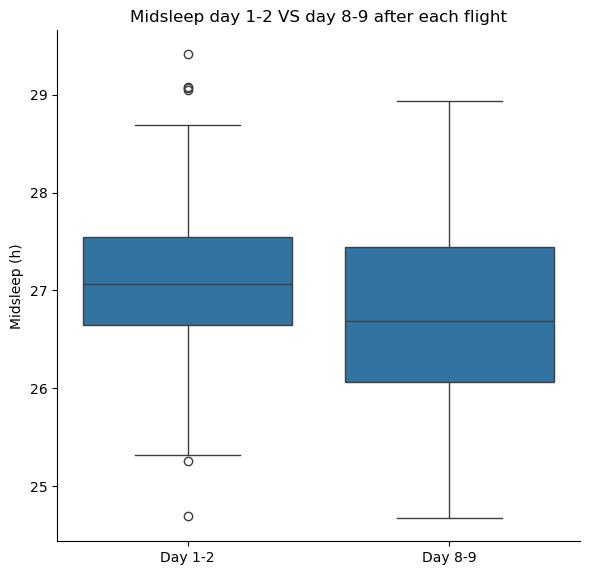

In [115]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='midsleep_h', data=df_flight1)
plt.title('Midsleep day 1-2 VS day 8-9 after each flight')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Midsleep (h)')
plt.xlabel('')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
#plt.ylim(18.5, 27)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

In [116]:
# Fit the factorial ANOVA model
model4 = ols('midsleep_h ~ C(location) * C(day_after_flight_group)', data=df_flight1).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model4, typ=2)

print(anova_results)

                                           sum_sq     df         F    PR(>F)
C(location)                              0.280199    1.0  0.342289  0.559346
C(day_after_flight_group)                4.429295    1.0  5.410798  0.021283
C(location):C(day_after_flight_group)    2.578665    1.0  3.150080  0.077849
Residual                               129.339267  158.0       NaN       NaN


In [117]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model5 = smf.mixedlm('midsleep_h ~ C(location) + day_after_flight + photoperiod + photoperiod*C(location) + C(location)*day_after_flight', 
                      data=df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model5.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        midsleep_h
No. Observations:        615            Method:                    REML      
No. Groups:              45             Scale:                     0.8140    
Min. group size:         1              Log-Likelihood:            -828.0406 
Max. group size:         46             Converged:                 Yes       
Mean group size:         13.7                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          26.463    0.293 90.185 0.000 25.888 27.038
C(location)[T.UK]                   0.944    0.401  2.354 0.019  0.158  1.730
day_after_flight                    0.009    0.006  1.410 0.159 -0.003  0.021
C(loca

In [118]:
# calculate log-likelihood of model2a
#ll_model5 = model5.llf
#ll_model5 = model5.llf

# calculate likelihood ratio Chi-Squared test statistic
#lr_test1 = 2 * (ll_model5 - model5.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
#p_value = stats.chi2.sf(lr_test1, 2)

#print('Likelihood ratio test results:')
#print('Chi-Squared test statistic:', lr_test1)
#print('P-value:', p_value)

In [119]:
coef_midsleep = pd.DataFrame({'coef': model5.params.values, 'p-value': model5.pvalues.values, '0.025': model5.conf_int()[0], '0.975': model5.conf_int()[1]})
coef_midsleep

,coef,p-value,0.025,0.975
Intercept,26.462664,0.000000,25.887561,27.037768
C(location)[T.UK],0.944109,0.018588,0.157933,1.730286
day_after_flight,0.008844,0.158514,-0.003449,0.021137
C(location)[T.UK]:day_after_flight,-0.035759,0.020122,-0.065916,-0.005602
photoperiod,0.030701,0.198086,-0.016053,0.077456
photoperiod:C(location)[T.UK],-0.071944,0.022846,-0.133898,-0.009990
Group Var,0.016631,0.449972,-0.026516,0.059778


In [120]:
#drop non significant variables
coef_midsleep = coef_midsleep.drop('Intercept')
coef_midsleep = coef_midsleep.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_15384\678367656.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location [T.UK]', 'Days after flight', 'Location[T.UK]*Days after flight', 'Photoperiod', 'Photoperiod*Location [T.UK]',], fontsize=9)


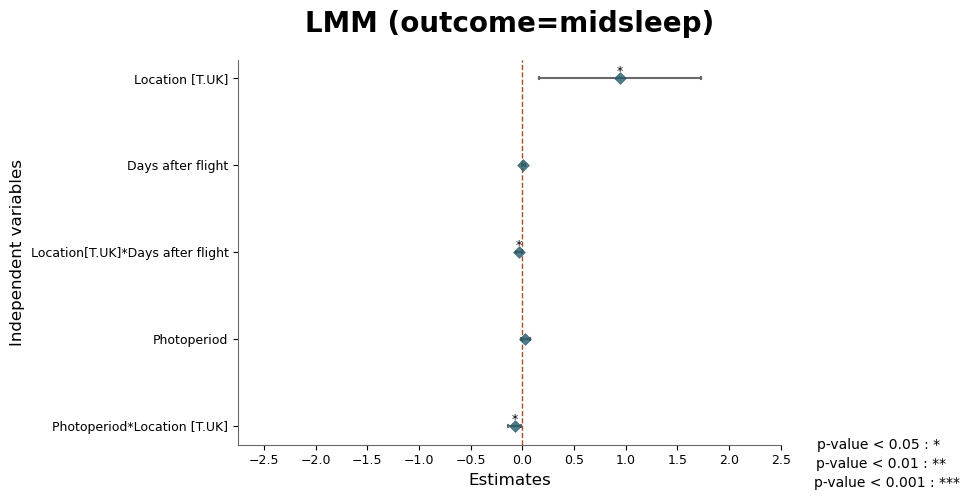

In [121]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_midsleep.index, data=coef_midsleep, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_midsleep.shape[0]):
    plt.plot([coef_midsleep['0.025'].iloc[i], coef_midsleep['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_midsleep['0.025'].iloc[i], coef_midsleep['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_midsleep['0.975'].iloc[i], coef_midsleep['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_midsleep.shape[0]):
    if coef_midsleep['p-value'].iloc[i] < 0.001:
        plt.text(coef_midsleep['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_midsleep['p-value'].iloc[i] < 0.01:
        plt.text(coef_midsleep['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_midsleep['p-value'].iloc[i] < 0.055:
        plt.text(coef_midsleep['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=midsleep)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location [T.UK]', 'Days after flight', 'Location[T.UK]*Days after flight', 'Photoperiod', 'Photoperiod*Location [T.UK]',], fontsize=9)

plt.show()

<Figure size 800x600 with 0 Axes>

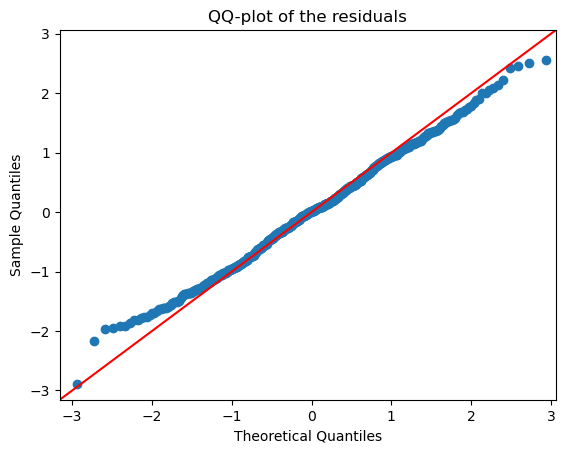

In [122]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [123]:
residualsY = model5.resid 
predictedY = model5.fittedvalues

In [124]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model5.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 4.28244106161061, p-value: 0.5095083478216226
The residuals are homoscedastic (fail to reject H0).


In [125]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

Durbin-Watson test: 1.6915521379762957


In [126]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

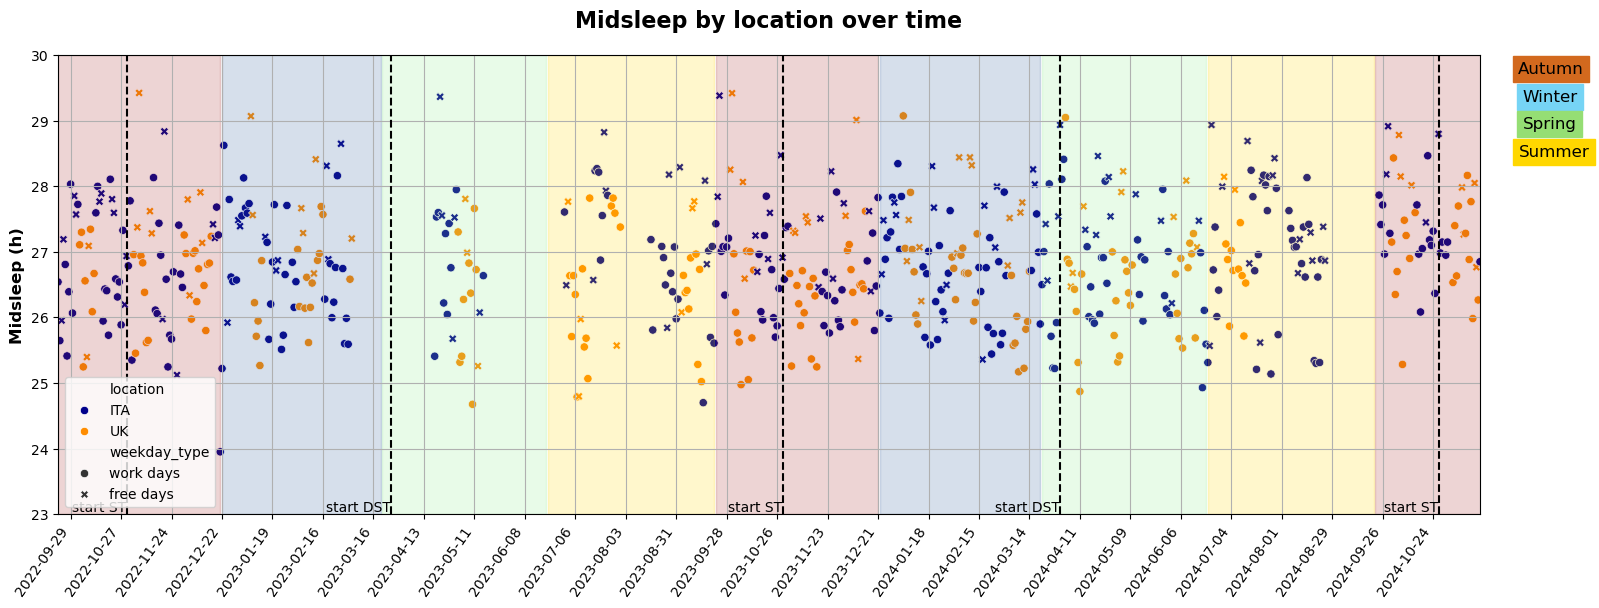

In [210]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.legend()
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca
plt.ylim(23,30)
# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.052, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.05, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.049, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.049, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

#plt.xlim(pd.to_datetime('2024-03-28'), pd.to_datetime('2024-04-27'))

plt.show()

_Phase (wake up time - sunrise)_

In [ ]:
df2 = df
df2_x = df_flight1

In [129]:
# test the skewness of the phase data
skewness = skew(df2['phase'])

print(f"Index of skewness: {skewness}")

Index of skewness: 0.5918967745358448


In [130]:
# test the kurtosis of the phase data
kurtosis_value = kurtosis(df2['phase'])

print(f"Index of kurtosis: {kurtosis_value}")

Index of kurtosis: -0.3210356946543511


In [131]:
#phase_data = df2['phase'].values.reshape(-1, 1)

# apply the Yeo-Johnson transformation
#pt = PowerTransformer(method='yeo-johnson')
#phase_transformed = pt.fit_transform(phase_data)

In [132]:
# add the transformed phase to the dataframe 
#df2['phase_transformed'] = phase_transformed

In [133]:
# test the best distribution for the phase data
distributions = ['norm', 'gamma', 'lognorm', 'expon']
best_fit_results = {}

In [134]:
# Filter out invalid values (e.g., negative values or zeros) for distributions that require positive values
valid_phase = df2["phase"][df2["phase"] > 0]

for dist_name in distributions:
    dist = getattr(stats, dist_name)
    if dist_name in ['gamma', 'lognorm', 'expon']:
        params = dist.fit(valid_phase)
        ks_stat, ks_pval = stats.kstest(valid_phase, dist_name, args=params)
    else:
        params = dist.fit(df2["phase"])
        ks_stat, ks_pval = stats.kstest(df2["phase"], dist_name, args=params)
    best_fit_results[dist_name] = ks_stat  # save the KS statistic

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\scipy\stats\_continuous_distns.py:6545: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


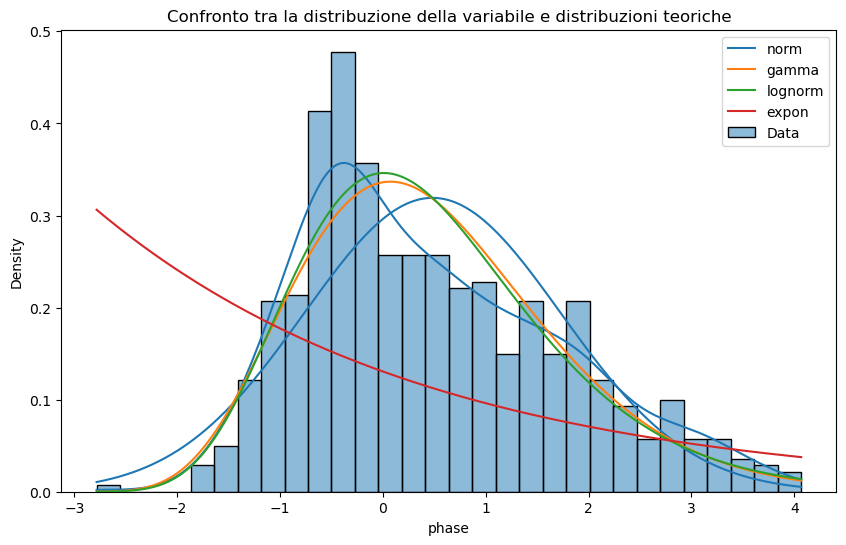

In [135]:
# plot of the best fit results
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df2["phase"], bins=30, kde=True, stat="density", label="Data", ax=ax)

x = np.linspace(df2["phase"].min(), df2["phase"].max(), 1000)

# Disegniamo le distribuzioni teoriche
for dist_name in best_fit_results.keys():
    dist = getattr(stats, dist_name)
    params = dist.fit(df2["phase"])
    pdf = dist.pdf(x, *params)
    ax.plot(x, pdf, label=f"{dist_name}")

ax.legend()
ax.set_title("Confronto tra la distribuzione della variabile e distribuzioni teoriche")
plt.show()

In [136]:
# Shapiro-Wilk test for the transformed phase
shapiro_test_phase = stats.shapiro(df2['phase'])
shapiro_test_phase

ShapiroResult(statistic=0.9607557309608654, pvalue=9.768933804823994e-12)

In [137]:
model1 = smf.mixedlm('phase ~ day_after_flight', df2, groups=df2['flight_id']).fit(method='powell')

print(model1.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  phase    
No. Observations:   614      Method:              REML     
No. Groups:         45       Scale:               0.7877   
Min. group size:    1        Log-Likelihood:      -862.5478
Max. group size:    46       Converged:           Yes      
Mean group size:    13.6                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.642    0.154  4.165 0.000  0.340  0.943
day_after_flight -0.014    0.006 -2.213 0.027 -0.027 -0.002
Group Var         0.881    0.240                           



In [138]:
model2 = smf.mixedlm('phase ~ day_after_flight + C(location) + C(location)*day_after_flight', df2, groups=df2['flight_id']).fit(method='powell')

print(model2.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        phase    
No. Observations:         614            Method:                    REML     
No. Groups:               45             Scale:                     0.7890   
Min. group size:          1              Log-Likelihood:            -866.0233
Max. group size:          46             Converged:                 Yes      
Mean group size:          13.6                                               
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.615    0.215  2.857 0.004  0.193  1.037
C(location)[T.UK]                   0.044    0.317  0.140 0.889 -0.577  0.666
day_after_flight                   -0.015    0.007 -2.040 0.041 -0.029 -0.001
C(loca

In [139]:
shapiro_test_midsleep = stats.shapiro(df2_x['phase'])

shapiro_test_midsleep

ShapiroResult(statistic=0.9485191626573815, pvalue=1.1945776526164068e-05)

In [140]:
utest_phase_days = stats.mannwhitneyu(df2_x[df2_x['day_after_flight_group'] == '0']['phase'], df2_x[df2_x['day_after_flight_group'] == '1']['phase'])

utest_phase_days

MannwhitneyuResult(statistic=3441.0, pvalue=0.5626323982899415)

In [141]:
# Fit the factorial ANOVA model
model4 = ols('phase ~ C(location) * C(day_after_flight_group)', data=df2_x).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model4, typ=2)

print(anova_results)

                                           sum_sq     df         F    PR(>F)
C(location)                              0.608206    1.0  0.339989  0.560667
C(day_after_flight_group)                0.933273    1.0  0.521702  0.471184
C(location):C(day_after_flight_group)    1.214613    1.0  0.678972  0.411183
Residual                               282.646298  158.0       NaN       NaN


In [187]:
# Fit a mixed-effects model with random intercepts for each day after flight
# re_formula="~1": This specifies that the random effects are independent and only include a random intercept for each group 
# i.e. each group has its own intercept, but the slopes are assumed to be the same across groups
model5a = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_1) + C(location)*photoperiod', data=df2, groups=df2['flight_id'], re_formula='~1').fit(method='powell', maxiter=1000)

print(model5a.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       phase    
No. Observations:       614           Method:                   REML     
No. Groups:             45            Scale:                    0.7615   
Min. group size:        1             Log-Likelihood:           -800.5389
Max. group size:        46            Converged:                Yes      
Mean group size:        13.6                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                     -4.452    0.325 -13.714 0.000 -5.089 -3.816
C(location)[T.UK]              0.354    0.367   0.965 0.335 -0.365  1.072
C(DST_1)[T.1]                 -0.688    0.125  -5.500 0.000 -0.934 -0.443
photoperiod                    0.453    0.031  14.633 0.

In [143]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model5b = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_1) + day_after_flight + photoperiod*C(location) + C(location)*day_after_flight', data=df2, groups=df2['flight_id']).fit(method='powell', maxiter=1000)

print(model5b.summary())

                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        phase    
No. Observations:          614            Method:                    REML     
No. Groups:                45             Scale:                     0.7623   
Min. group size:           1              Log-Likelihood:            -807.7004
Max. group size:           46             Converged:                 Yes      
Mean group size:           13.6                                               
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                          -4.473    0.340 -13.156 0.000 -5.139 -3.806
C(location)[T.UK]                   0.467    0.394   1.184 0.236 -0.306  1.239
C(DST_1)[T.1]                      -0.694    0.126  -5.491 0.000 -0.942 -

In [188]:
# calculate log-likelihood of model2a
ll_model5a = model5a.llf
ll_model5b = model5b.llf

# calculate likelihood ratio Chi-Squared test statistic
lr_test1 = 2 * (ll_model5a - model5b.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
p_value = stats.chi2.sf(lr_test1, 2)

print('Likelihood ratio test results:')
print('Chi-Squared test statistic:', lr_test1)
print('P-value:', p_value)

Likelihood ratio test results:
Chi-Squared test statistic: 14.323007414069252
P-value: 0.0007758869688920077


In [189]:
coef_phase = pd.DataFrame({'coef': model5a.params.values, 'p-value': model5a.pvalues.values, '0.025': model5a.conf_int()[0], '0.975': model5a.conf_int()[1]})
coef_phase

,coef,p-value,0.025,0.975
Intercept,-4.452484,8.337841e-43,-5.088807,-3.816162
C(location)[T.UK],0.353621,3.347187e-01,-0.364860,1.072103
C(DST_1)[T.1],-0.688299,3.803541e-08,-0.933591,-0.443007
photoperiod,0.452656,1.739415e-48,0.392025,0.513287
C(location)[T.UK]:photoperiod,-0.024663,4.227516e-01,-0.084961,0.035635
Group Var,0.016682,4.920142e-01,-0.030904,0.064268


In [190]:
#drop non significant variables
coef_phase = coef_phase.drop('Intercept')
coef_phase = coef_phase.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_15384\3266223409.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.DST]', 'Photoperiod', 'Location[T.UK]*Photoperiod'])


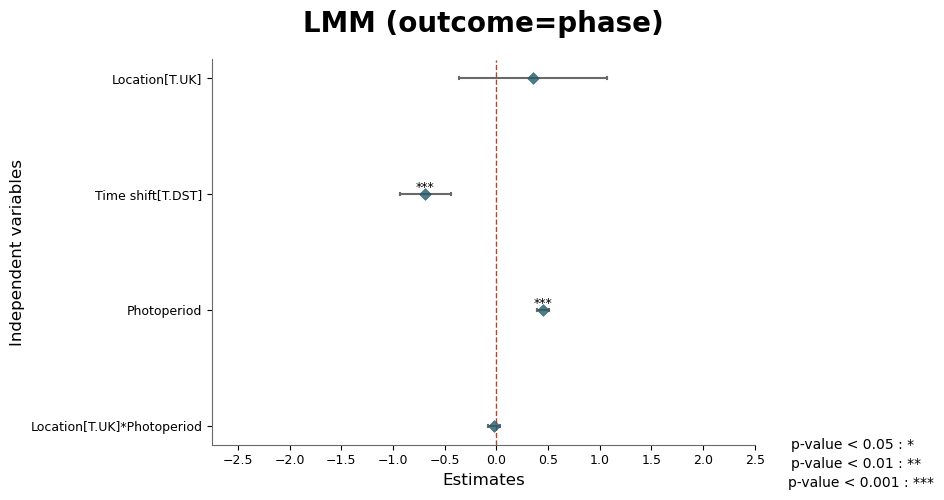

In [191]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_phase.index, data=coef_phase, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_phase.shape[0]):
    plt.plot([coef_phase['0.025'].iloc[i], coef_phase['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_phase['0.025'].iloc[i], coef_phase['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_phase['0.975'].iloc[i], coef_phase['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_phase.shape[0]):
    if coef_phase['p-value'].iloc[i] < 0.001:
        plt.text(coef_phase['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_phase['p-value'].iloc[i] < 0.01:
        plt.text(coef_phase['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_phase['p-value'].iloc[i] < 0.05:
        plt.text(coef_phase['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=phase)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.DST]', 'Photoperiod', 'Location[T.UK]*Photoperiod'])

plt.show()

<Figure size 800x600 with 0 Axes>

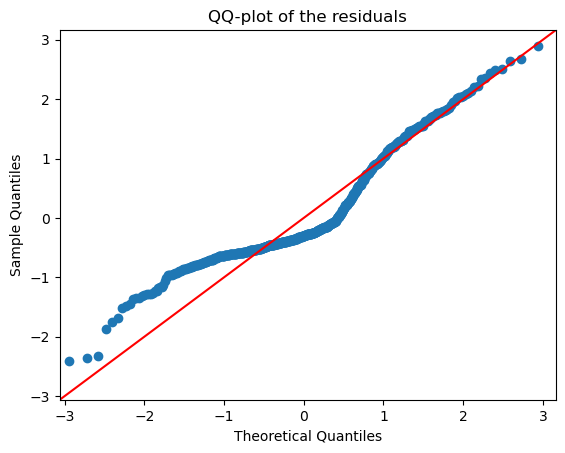

In [148]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5b.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [149]:
residualsX = model5b.resid 
predictedX = model5b.fittedvalues

In [150]:
# Breusch-Pagan test for homoscedasticity
bp_testX = het_breuschpagan(residualsX, model5b.model.exog)

# results of the Breusch-Pagan test
bp_statX, bp_pvalX, _, _ = bp_testX
print(f'Breusch-Pagan statistic: {bp_statX}, p-value: {bp_pvalX}')
if bp_pvalX > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 11.868704829363608, p-value: 0.06496275670029497
The residuals are homoscedastic (fail to reject H0).


In [151]:
# Durbin-Watson test for autocorrelation
durbin_watson_testX = durbin_watson(residualsX)

print('Durbin-Watson test:', durbin_watson_testX)

Durbin-Watson test: 1.6925371888145122


In [152]:
# Order the dat to fit the GEE model
df2 = df2.sort_values(by='date')

# define the structure of the GEE model(Autoregressive) to capture the temporal dependence
cov_str = sm.cov_struct.Autoregressive() # For longitudinal data: proximate data points exhibit stronger correlation than distant data points

# GEE model with random intercepts for each date
gee_model = smf.gee(
    'phase ~ C(location) + C(DST_1) + day_after_flight + photoperiod + C(location)*photoperiod + C(location)*day_after_flight',
    data=df2,
    groups=df2['flight_id'],  # to model the intra-day post-flight correlation: 
                                     # if the day after flight affects sleep in a systematic way and if observations from the same day_after_flight are more similar to each other than observations from different days
    cov_struct=cov_str,
    family=sm.families.Gaussian()
).fit()

gee_model.summary()

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\statsmodels\genmod\cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                       phase   No. Observations:                  614
Model:                                 GEE   No. clusters:                       45
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  46
Family:                           Gaussian   Mean cluster size:                13.6
Dependence structure:       Autoregressive   Num. iterations:                    15
Date:                     Wed, 26 Feb 2025   Scale:                           0.774
Covariance type:                    robust   Time:                         12:42:03
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -4.3895      0.281    -15.608      0.000      -4.941      -3.838
C(location)[T.UK]                      0.4138      0.342      1.209      0.227      -0.257       1.085
C(DST_1)[T.1]                         -0.6744      0.099     -6.825      0.000      -0.868      -0.481
day_after_flight                       0.0003      0.008      0.036      0.972      -0.016       0.017
C(location)[T.UK]:day_after_flight    -0.0123      0.014     -0.869      0.385      -0.040       0.015
photoperiod                            0.4468      0.028     15.788      0.000       0.391       0.502
C(location)[T.UK]:photoperiod         -0.0221      0.030     -0.747      0.455      -0.080       0.036
==============================================================================
Skew:                          0.8798   Kurtosis:                       0.4238
Centered skew:                 0.8216   Centered kurtosis:              0.5763
==============================================================================
"""

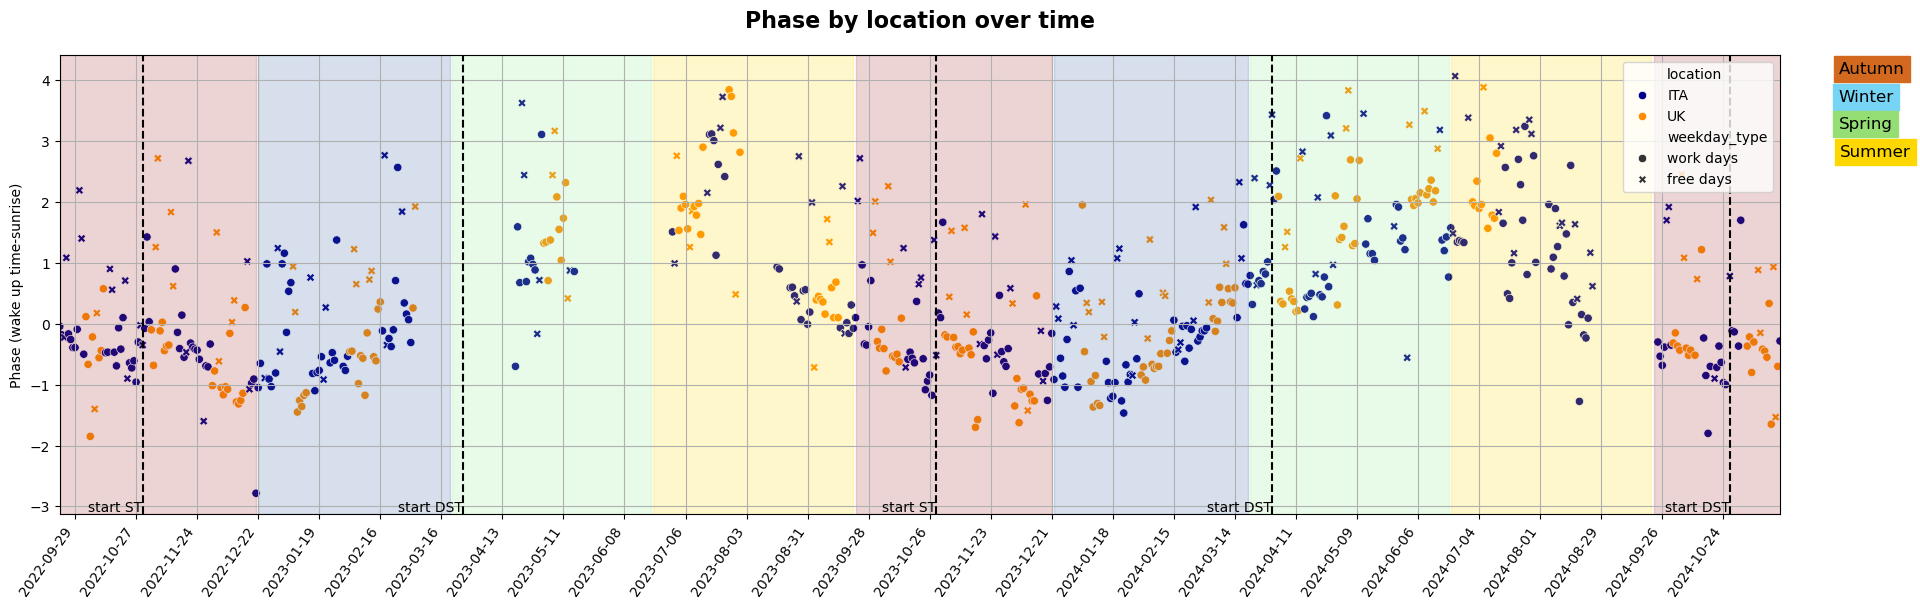

In [196]:
plt.figure(figsize=(18, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

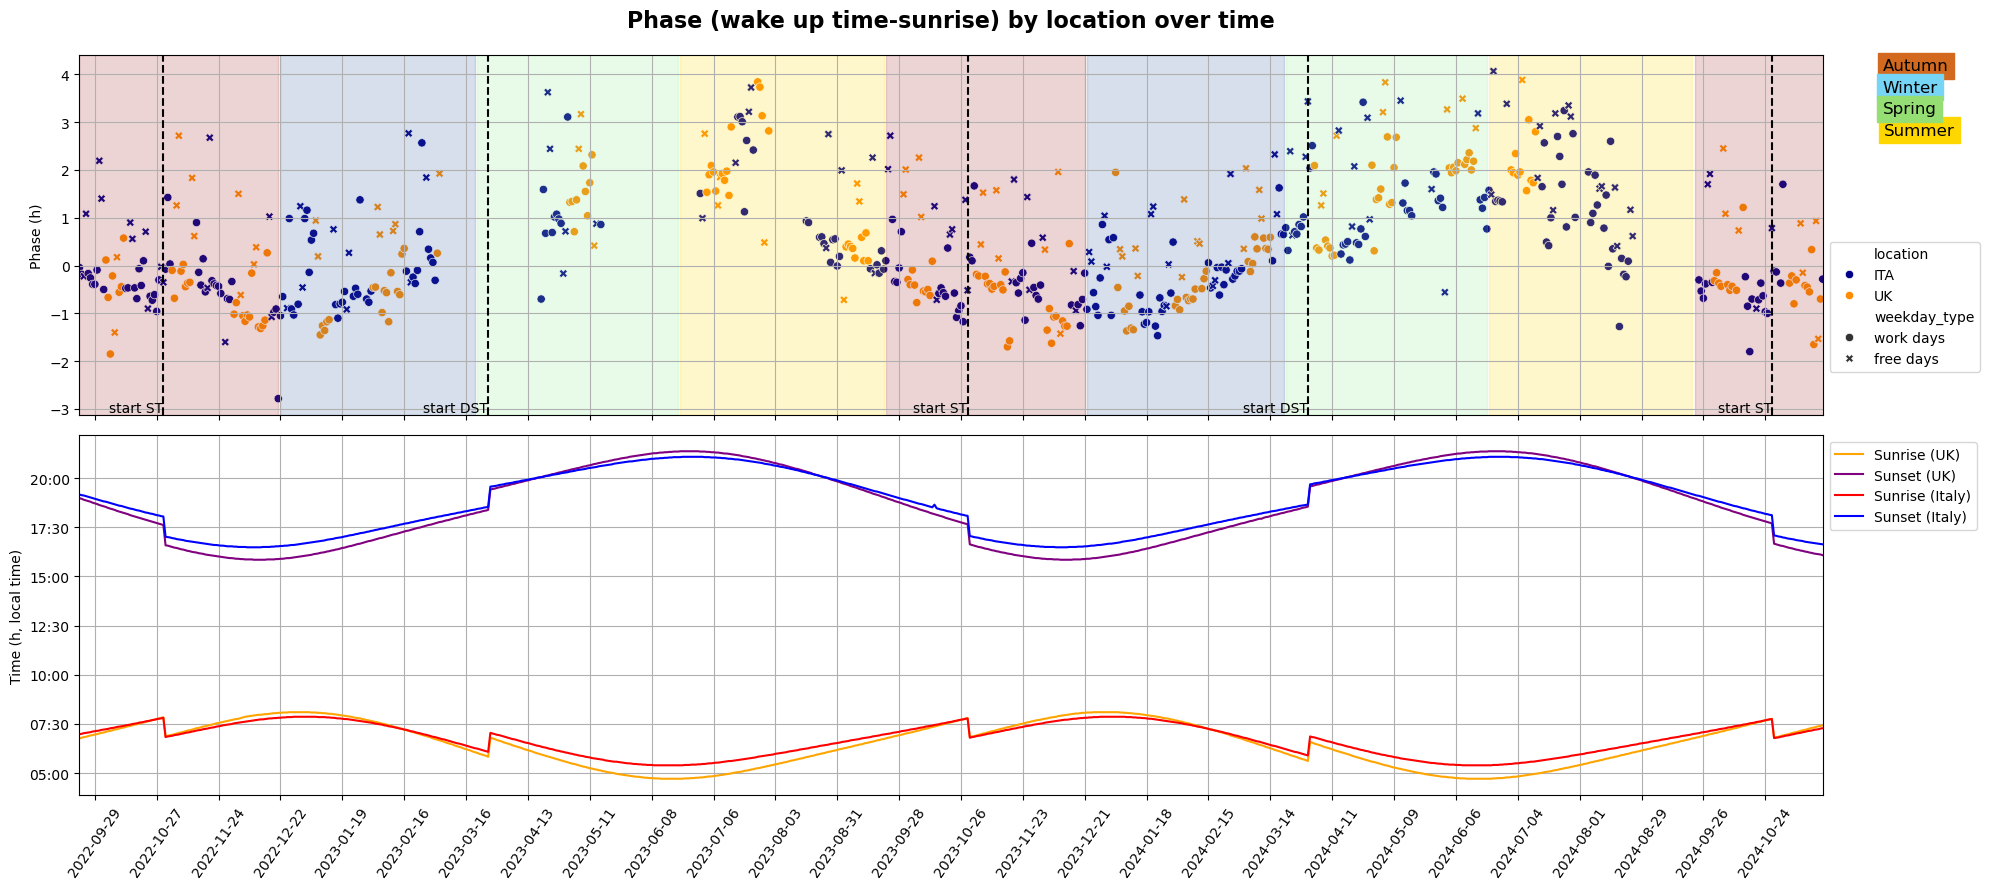

In [207]:
# Create a figure with two subplots (one above the other) with adjusted height ratios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 9), sharex=True, gridspec_kw={'height_ratios': [5, 5]})

# Plot the phase by location over time in the top subplot
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'], ax=ax1)
ax1.set_title('Phase (wake up time-sunrise) by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
ax1.set_ylabel('Phase (h)')
ax1.set_xlabel('')
ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='x', rotation=55)
ax1.set_xlim(df2['date'].min(), df2['date'].max())
ax1.xaxis.set_major_locator(MultipleLocator(28))  # Set the x-axis major locator

#  set the legend outside the plot
ax1.legend(loc='upper left', bbox_to_anchor=(1, 0.5))

# Add vertical bars to indicate the start of DST and ST
dst_st_dates = [
    ('2022-10-30', 'start ST'),
    ('2023-10-29', 'start ST'),
    ('2023-03-26', 'start DST'),
    ('2024-03-31', 'start DST'),
    ('2024-10-27', 'start ST')
]
for date, label in dst_st_dates:
    ax1.axvline(x=pd.to_datetime(date), color='black', linestyle='--')
    ax1.text(pd.to_datetime(date), ax1.get_ylim()[0], label, ha='right', va='bottom')

# Define seasons and apply background color for each season
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]
for start, end, color in seasons:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

# Annotate the seasons
season_annotations = [
    ('Summer', 1.0555, 0.79, 'gold'),
    ('Autumn', 1.0535, 0.97, 'chocolate'),
    ('Winter', 1.05, 0.91, '#76d4f5'),
    ('Spring', 1.0499, 0.85, '#95de74')
]
for label, x, y, color in season_annotations:
    ax1.annotate(label, xy=(x, y), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor=color)

# Plot the sunrise and sunset times in the bottom subplot
sns.lineplot(x='date', y='sunrise (uk), hours_adjust', data=df_daylight1, ax=ax2, label='Sunrise (UK)', color='orange')
sns.lineplot(x='date', y='sunset (uk), hours_adjust', data=df_daylight1, ax=ax2, label='Sunset (UK)', color='purple')
sns.lineplot(x='date', y='sunrise (ita), hours_adjust', data=df_daylight1, ax=ax2, label='Sunrise (Italy)', color='red')
sns.lineplot(x='date', y='sunset (ita), hours_adjust', data=df_daylight1, ax=ax2, label='Sunset (Italy)', color='blue')

ax2.set_ylabel('Time (h, local time)')
ax2.set_xlabel('')
# Format y-axis to hh:mm
ax2.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))
ax2.grid(True)
ax2.tick_params(axis='x', rotation=55)
ax2.set_xlim(df2['date'].min(), df2['date'].max())
ax2.xaxis.set_major_locator(MultipleLocator(28))  # Set the x-axis major locator

#  set the legend outside the plot
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


Wake After Sleep Onset

In [155]:
# drop the nan values in the waso_min column
df_waso_clean = df.dropna(subset=['waso'])
df_waso_clean_x = df_flight1.dropna(subset=['waso'])

In [156]:
model1a = smf.mixedlm('waso ~ day_after_flight', df_waso_clean, groups=df_waso_clean['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1a.summary())

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  waso      
No. Observations:  612      Method:              REML      
No. Groups:        45       Scale:               848.0890  
Min. group size:   1        Log-Likelihood:      -2948.5832
Max. group size:   45       Converged:           Yes       
Mean group size:   13.6                                    
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        51.126    2.458 20.804 0.000 46.309 55.942
day_after_flight  0.033    0.198  0.165 0.869 -0.356  0.421
Group Var        85.222    1.182                           



In [157]:
model2 = smf.mixedlm('waso ~ day_after_flight + C(location) + C(location)*day_after_flight', df_waso_clean, groups=df_waso_clean['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        waso      
No. Observations:        612            Method:                    REML      
No. Groups:              45             Scale:                     841.1394  
Min. group size:         1              Log-Likelihood:            -2937.1527
Max. group size:         45             Converged:                 Yes       
Mean group size:         13.6                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          42.569    2.983 14.270 0.000 36.722 48.416
C(location)[T.UK]                  21.446    4.969  4.316 0.000 11.706 31.186
day_after_flight                    0.352    0.215  1.642 0.101 -0.068  0.773
C(loca

In [158]:
shapiro_test_midsleep = stats.shapiro(df_waso_clean_x['waso'])

shapiro_test_midsleep

ShapiroResult(statistic=0.981995097196402, pvalue=0.034299318049128655)

In [159]:
ttest_midsleep_days = stats.ttest_ind(df_waso_clean_x[df_waso_clean_x['day_after_flight_group'] == '0']['waso'], df_waso_clean_x[df_waso_clean_x['day_after_flight_group'] == '1']['waso'])

ttest_midsleep_days

TtestResult(statistic=-1.723724874584489, pvalue=0.0867012884844268, df=159.0)

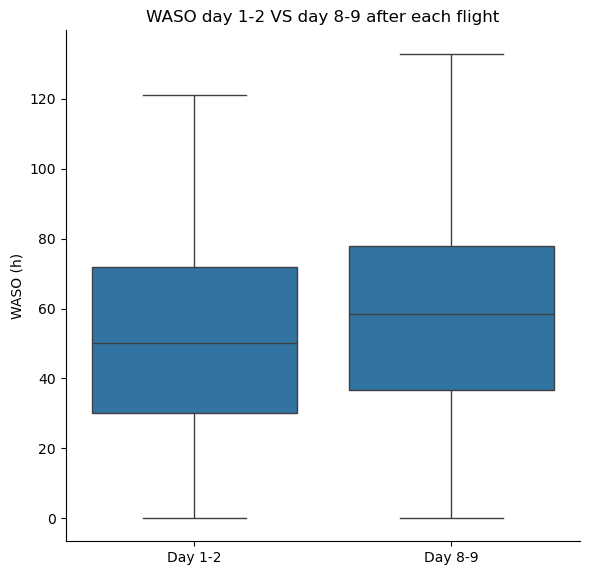

In [160]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='waso', data=df_waso_clean_x)
plt.title('WASO day 1-2 VS day 8-9 after each flight')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('WASO (h)')
plt.xlabel('')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
#plt.ylim(18.5, 27)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

In [161]:
# Fit the factorial ANOVA model
model4 = ols('waso ~ C(location) * C(day_after_flight_group)', data=df_waso_clean_x).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model4, typ=2)

print(anova_results)

                                              sum_sq     df         F  \
C(location)                              7870.760138    1.0  9.460193   
C(day_after_flight_group)                2573.195190    1.0  3.092830   
C(location):C(day_after_flight_group)    1378.413400    1.0  1.656772   
Residual                               130622.002779  157.0       NaN   

                                         PR(>F)  
C(location)                            0.002478  
C(day_after_flight_group)              0.080586  
C(location):C(day_after_flight_group)  0.199934  
Residual                                    NaN  
